## Verify Project Directory

Before loading any data, the current working directory is checked to ensure that all dataset paths and project files can be accessed correctly.

In [3]:
import os

print(os.getcwd())

C:\Users\Aditya Venugopalan\Medical-Image-Classification-CNN


## Verify Dataset Structure

The Chest X-Ray dataset follows a train, validation and test folder structure. This cell checks that all required directories exist before data loading and preprocessing.

In [4]:
import os

base_dir = "data/chest_xray"

train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")
val_dir = os.path.join(base_dir, "val")

print("Train exists:", os.path.exists(train_dir))
print("Test exists:", os.path.exists(test_dir))
print("Val exists:", os.path.exists(val_dir))

Train exists: True
Test exists: True
Val exists: True


## Class Distribution Analysis

Before training, the number of images in each class is examined to identify any class imbalance. Understanding class distribution is important because heavily imbalanced datasets can bias a model toward the majority class.

In [5]:
normal_train = len(os.listdir(os.path.join(train_dir, "NORMAL")))
pneumonia_train = len(os.listdir(os.path.join(train_dir, "PNEUMONIA")))

normal_test = len(os.listdir(os.path.join(test_dir, "NORMAL")))
pneumonia_test = len(os.listdir(os.path.join(test_dir, "PNEUMONIA")))

print("Train NORMAL:", normal_train)
print("Train PNEUMONIA:", pneumonia_train)
print("Test NORMAL:", normal_test)
print("Test PNEUMONIA:", pneumonia_test)

Train NORMAL: 1342
Train PNEUMONIA: 3876
Test NORMAL: 234
Test PNEUMONIA: 390


### Observation

The dataset contains substantially more pneumonia images than normal images. This class imbalance may influence model behaviour and was considered during later experiments involving class weighting and threshold analysis.

## Visual Inspection of Dataset Samples

Before preprocessing and model training, a sample image from each class was visualised. This step helps verify that images load correctly, labels are assigned appropriately, and the dataset contains meaningful visual differences between the NORMAL and PNEUMONIA classes.

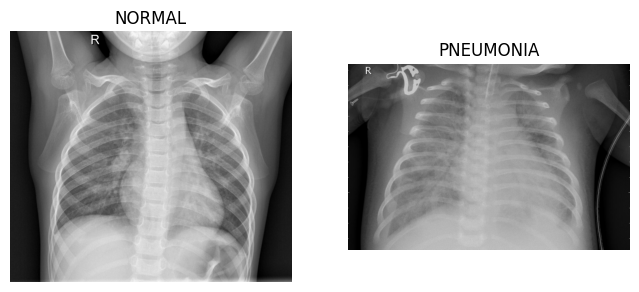

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Get only image files (ignore .DS_Store etc.)
normal_files = [f for f in os.listdir(os.path.join(train_dir, "NORMAL")) if f.endswith(".jpeg")]
pneumonia_files = [f for f in os.listdir(os.path.join(train_dir, "PNEUMONIA")) if f.endswith(".jpeg")]

# Pick first valid image
normal_path = os.path.join(train_dir, "NORMAL", normal_files[0])
pneumonia_path = os.path.join(train_dir, "PNEUMONIA", pneumonia_files[0])

# Open images
normal_img = Image.open(normal_path)
pneumonia_img = Image.open(pneumonia_path)

# Plot
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(normal_img, cmap="gray")
plt.title("NORMAL")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pneumonia_img, cmap="gray")
plt.title("PNEUMONIA")
plt.axis("off")

plt.show()

### Observation

The sample pneumonia image displays increased lung opacity compared to the normal image. While a single image is not representative of the entire dataset, this visual inspection confirms that the classes contain distinguishable patterns that can potentially be learned by deep learning models.

## Dataset Distribution

To better understand the dataset composition, the number of images in each class was calculated for the training, testing and validation sets. This helps identify potential class imbalance that could influence model performance during training.

## Class Percentage Distribution

To quantify the degree of class imbalance, the percentage of NORMAL and PNEUMONIA images was calculated for each dataset split.

In [7]:
import os

# Function to count image files
def count_images(folder_path):
    image_files = [
        file for file in os.listdir(folder_path)
        if file.lower().endswith((".jpeg", ".jpg", ".png"))
    ]
    return len(image_files)

# Training counts
train_normal_count = count_images(os.path.join(train_dir, "NORMAL"))
train_pneumonia_count = count_images(os.path.join(train_dir, "PNEUMONIA"))

# Testing counts
test_normal_count = count_images(os.path.join(test_dir, "NORMAL"))
test_pneumonia_count = count_images(os.path.join(test_dir, "PNEUMONIA"))

# Validation counts
val_normal_count = count_images(os.path.join(val_dir, "NORMAL"))
val_pneumonia_count = count_images(os.path.join(val_dir, "PNEUMONIA"))

# Print
print("Train NORMAL:", train_normal_count)
print("Train PNEUMONIA:", train_pneumonia_count)
print("Test NORMAL:", test_normal_count)
print("Test PNEUMONIA:", test_pneumonia_count)
print("Val NORMAL:", val_normal_count)
print("Val PNEUMONIA:", val_pneumonia_count)

Train NORMAL: 1341
Train PNEUMONIA: 3875
Test NORMAL: 234
Test PNEUMONIA: 390
Val NORMAL: 8
Val PNEUMONIA: 8


In [8]:
total_train = train_normal_count + train_pneumonia_count
total_test = test_normal_count + test_pneumonia_count
total_val = val_normal_count + val_pneumonia_count

train_normal_pct = (train_normal_count / total_train) * 100
train_pneumonia_pct = ( train_pneumonia_count / total_train) * 100

test_normal_pct = (test_normal_count / total_test) * 100
test_pneumonia_pct = (test_pneumonia_count / total_test) * 100

val_normal_pct = ( val_normal_count / total_val) * 100
val_pneumonia_pct = ( val_pneumonia_count / total_val) * 100

# Print results
print("=== TRAIN DATA ===")
print(f"NORMAL: {train_normal_count} ({train_normal_pct:.2f}%)")
print(f"PNEUMONIA: {train_pneumonia_count} ({train_pneumonia_pct:.2f}%)")

print("\n=== TEST DATA ===")
print(f"NORMAL: {test_normal_count} ({test_normal_pct:.2f}%)")
print(f"PNEUMONIA: {test_pneumonia_count} ({test_pneumonia_pct:.2f}%)")

print("\n=== VALIDATION DATA ===")
print(f"NORMAL: {val_normal_count} ({val_normal_pct:.2f}%)")
print(f"PNEUMONIA: {val_pneumonia_count} ({val_pneumonia_pct:.2f}%)")


=== TRAIN DATA ===
NORMAL: 1341 (25.71%)
PNEUMONIA: 3875 (74.29%)

=== TEST DATA ===
NORMAL: 234 (37.50%)
PNEUMONIA: 390 (62.50%)

=== VALIDATION DATA ===
NORMAL: 8 (50.00%)
PNEUMONIA: 8 (50.00%)


### Observation

The training dataset is heavily skewed towards pneumonia cases, with approximately 74% of images belonging to the PNEUMONIA class. Such class imbalance can bias a model towards the majority class and may negatively impact the detection of normal cases. This observation motivated later experiments involving class weighting and threshold analysis.

## Training Dataset Class Distribution

To better understand the level of class imbalance, the number of images belonging to each class was visualised using a bar chart. Visual representations make it easier to identify whether one class dominates the dataset.

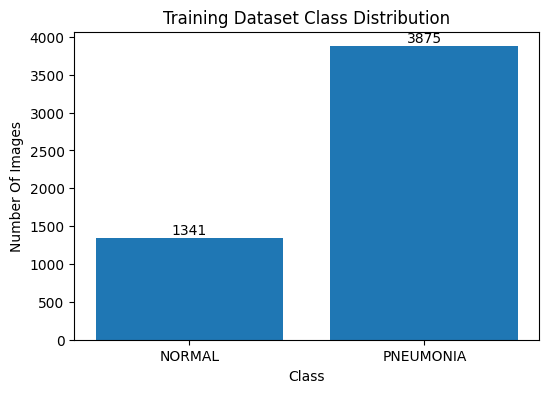

In [9]:
import matplotlib.pyplot as plt

classes = ["NORMAL" , "PNEUMONIA"]

train_counts = [train_normal_count, train_pneumonia_count]

plt.figure(figsize=(6,4))

plt.bar( classes, train_counts)

plt.title("Training Dataset Class Distribution")

plt.xlabel("Class")
plt.ylabel("Number Of Images")

for i, count in enumerate(train_counts):
    plt.text(i, count + 50, str(count), ha='center')

plt.show()

### Observation

The training dataset contains substantially more pneumonia images than normal images. This imbalance may influence model predictions by encouraging the model to favour the majority class. Consequently, later experiments explored class weighting and threshold analysis to better understand and address the effects of class imbalance.

## Visualising Multiple Random Samples

While a single image provides an initial impression of each class, examining multiple random samples offers a better understanding of the variability present within the dataset. This helps identify differences in patient positioning, image quality and disease presentation that the model must learn to handle.

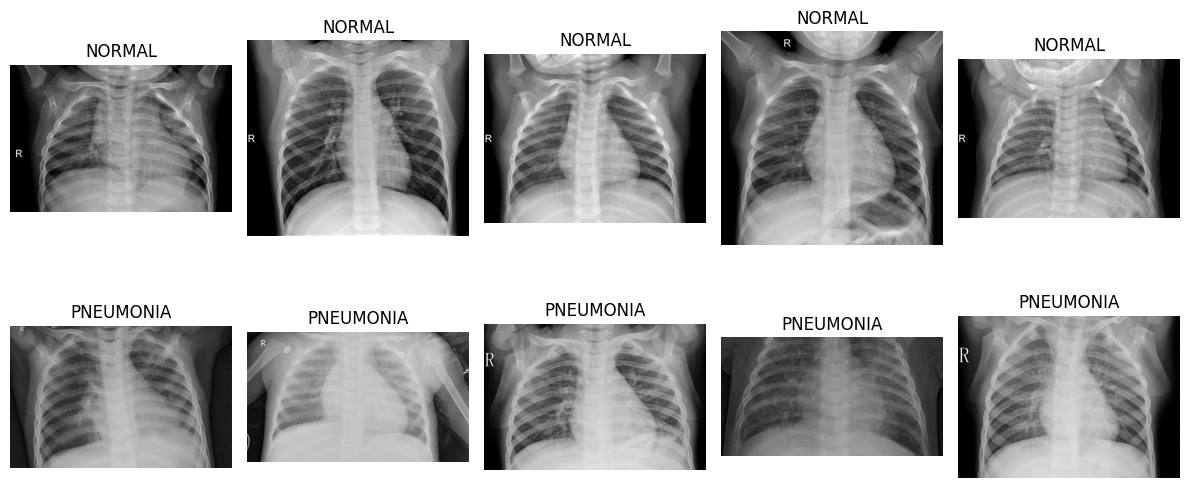

In [10]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Getting image file names

normal_files = [
    file for file in os.listdir(os.path.join(train_dir, "NORMAL"))
    if file.endswith(".jpeg")
]

pneumonia_files = [
    file for file in os.listdir(os.path.join(train_dir, "PNEUMONIA"))
    if file.endswith(".jpeg")
]

plt.figure(figsize=(12,6))

# For Normal Images

for i in range(5):
    # Random image selection

    img_name = random.choice(normal_files)

    img_path = os.path.join(train_dir, "NORMAL", img_name)

    img = Image.open(img_path)

    plt.subplot(2,5,i+1)
    plt.imshow(img, cmap="gray")
    plt.title("NORMAL")
    plt.axis("off")

# Show PNEUMONIA images
for i in range(5):

    img_name = random.choice(pneumonia_files)

    img_path = os.path.join(train_dir, "PNEUMONIA", img_name)

    img = Image.open(img_path)

    plt.subplot(2,5,i+6)
    plt.imshow(img, cmap="gray")
    plt.title("PNEUMONIA")
    plt.axis("off")

# Show final output
plt.tight_layout()
plt.show()

    

### Observation

The images demonstrate noticeable variation within both classes. Differences in image brightness, positioning and anatomical appearance can be observed across patients. Pneumonia cases also show varying levels of lung opacity, highlighting the complexity of the classification task.

In [11]:
from PIL import Image
import os

def get_image_sizes(folder_path):
    sizes = []

    for file in os.listdir(folder_path):
        if file.lower().endswith((".jpeg",".jpg",".png")):
            img_path = os.path.join(folder_path, file)
            img = Image.open(img_path)
            sizes.append(img.size)
    return sizes

normal_sizes = get_image_sizes(os.path.join(train_dir, "NORMAL"))
pneumonia_sizes = get_image_sizes(os.path.join(train_dir, "PNEUMONIA"))

print("First 10 NORMAL image sizes:")
print(normal_sizes[:10])

print("First 10 Pneumonia image sizes:")
print(pneumonia_sizes[:10])

print("\nUnique NORMAL image sizes:", len(set(normal_sizes)))
print("Unique PNEUMONIA image sizes:", len(set(pneumonia_sizes)))
            
        

First 10 NORMAL image sizes:
[(2090, 1858), (1422, 1152), (1810, 1434), (1618, 1279), (1600, 1125), (1974, 1306), (1528, 1013), (1384, 1167), (1450, 1144), (1468, 993)]
First 10 Pneumonia image sizes:
[(1152, 760), (1072, 768), (1244, 863), (1242, 940), (1488, 1280), (1008, 616), (1184, 816), (856, 480), (1048, 888), (1216, 792)]

Unique NORMAL image sizes: 1325
Unique PNEUMONIA image sizes: 3060


## Image Integrity Check

Before preprocessing and model training, all image files were checked to ensure they could be opened successfully. This helps identify corrupted or unreadable files that could cause errors during model training.

In [146]:
from PIL import Image
import os

def check_corrupted_images(folder_path):
    corrupted_files = []

    for file in os.listdir(folder_path):
        if file.lower().endswith((".jpeg", ".jpg", ".png")):
            img_path = os.path.join(folder_path, file)

            try:
                img = Image.open(img_path)
                img.verify()

            except:
                corrupted_files.append(img_path)

    return corrupted_files


folders_to_check = [
    os.path.join(train_dir, "NORMAL"),
    os.path.join(train_dir, "PNEUMONIA"),
    os.path.join(test_dir, "NORMAL"),
    os.path.join(test_dir, "PNEUMONIA"),
    os.path.join(val_dir, "NORMAL"),
    os.path.join(val_dir, "PNEUMONIA")
]

all_corrupted_files = []

for folder in folders_to_check:
    corrupted = check_corrupted_images(folder)
    all_corrupted_files.extend(corrupted)

print("Number of corrupted images:", len(all_corrupted_files))

if len(all_corrupted_files) > 0:
    print("Corrupted files:")
    for file in all_corrupted_files:
        print(file)
else:
    print("No corrupted images found.")

Number of corrupted images: 0
No corrupted images found.


### Observation

No corrupted images were identified during the integrity check. This indicates that all image files could be opened successfully and were suitable for preprocessing and model training.

## Image Size Analysis

Chest X-ray images in the dataset were checked to determine whether they shared the same dimensions. Since convolutional neural networks require a consistent input shape, this analysis helps justify resizing all images to 224 × 224 pixels during preprocessing.

## Brightness Analysis

The average brightness of NORMAL and PNEUMONIA images was calculated to check whether there were major differences in pixel intensity between the two classes. This helps identify whether the model may be influenced by overall image brightness rather than disease-related visual patterns.

In [12]:
import numpy as np
from PIL import Image
import os

# Function to calculate brightness
def calculate_brightness(folder_path):

    brightness_values = []

    for file in os.listdir(folder_path):

        # Keep valid image files only
        if file.lower().endswith((".jpeg", ".jpg", ".png")):

            try:
                # Create image path
                img_path = os.path.join(folder_path, file)

                # Open image and convert to grayscale
                img = Image.open(img_path).convert("L")

                # Convert image into numpy array
                img_array = np.array(img)

                # Calculate average brightness
                brightness = img_array.mean()

                # Save brightness value
                brightness_values.append(brightness)

            except:
                # Skip corrupted or unreadable files
                pass

    return brightness_values

# Calculate brightness
normal_brightness = calculate_brightness(os.path.join(train_dir, "NORMAL"))
pneumonia_brightness = calculate_brightness(os.path.join(train_dir, "PNEUMONIA"))

# Print results
print("NORMAL average brightness:", np.mean(normal_brightness))
print("PNEUMONIA average brightness:", np.mean(pneumonia_brightness))

NORMAL average brightness: 122.3763184468846
PNEUMONIA average brightness: 123.1998584238347


- The dataset contains two classes: NORMAL and PNEUMONIA.
- The training data is imbalanced, with more PNEUMONIA images than NORMAL images.
- Multiple sample images were visualized from both classes.
- The images are grayscale chest X-rays.
- Image dimensions are not consistent across the dataset.
- NORMAL images had 1325 unique image sizes.
- PNEUMONIA images had 3060 unique image sizes.
- Because image sizes are inconsistent, all images must be resized during preprocessing.
- Average brightness is very similar between the two classes.
- NORMAL average brightness was approximately 122.38.
- PNEUMONIA average brightness was approximately 123.20.

### Observation

The average brightness values for the NORMAL and PNEUMONIA classes were very similar. This suggests that the model is unlikely to rely only on overall brightness differences and instead needs to learn more detailed visual features from the chest X-rays.

### Observation

The dataset contains images with many different dimensions. NORMAL images had 1325 unique image sizes and PNEUMONIA images had 3060 unique image sizes. This confirms that resizing was required before model training so that every image had a consistent input shape.

## Dataset Path Verification

Before loading images, the dataset directory structure was verified to ensure that the base directory and train, test and validation folders were available. This helps prevent file path errors during preprocessing and model training.

In [13]:
import os
base_dir = "data/chest_xray"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")
val_dir = os.path.join(base_dir, "val")

print("Base directory exists:", os.path.exists(base_dir))
print("Train directory exists:", os.path.exists(train_dir))
print("Test directory exists:", os.path.exists(test_dir))
print("Validation directory exists:", os.path.exists(val_dir))

Base directory exists: True
Train directory exists: True
Test directory exists: True
Validation directory exists: True


### Observation

All dataset directories were successfully located. This confirmed that the project structure was configured correctly and that the train, test and validation datasets were available for further analysis.

## Class Folder Verification

The contents of the train, test and validation directories were inspected to confirm that both class folders (NORMAL and PNEUMONIA) were present in each dataset split.

In [14]:
# Check folders inside train/test/val

print("Train folders:")
print(os.listdir(train_dir))

print("\nTest folders:")
print(os.listdir(test_dir))

print("\nValidation folders:")
print(os.listdir(val_dir))

Train folders:
['.DS_Store', 'NORMAL', 'PNEUMONIA']

Test folders:
['.DS_Store', 'NORMAL', 'PNEUMONIA']

Validation folders:
['NORMAL', 'PNEUMONIA']


### Observation

Both NORMAL and PNEUMONIA folders were present in the train, test and validation datasets. This confirms that the binary classification problem is represented consistently across all dataset splits.

## Valid Image File Verification

A check was performed to count only valid image file formats (.jpeg, .jpg and .png). This ensures that the dataset contains usable image files and excludes unrelated files that could interfere with preprocessing or training.

In [15]:
def count_valid_images(folder_path):
    valid_extensions = (".jpeg",".jpg",".png")

    valid_images = [
        file for file in os.listdir(folder_path)
        if file.lower().endswith(valid_extensions)
    ]
    return len(valid_images)

train_normal_valid = count_valid_images(os.path.join(train_dir, "NORMAL"))
train_pneumonia_valid = count_valid_images(os.path.join(train_dir, "PNEUMONIA"))

test_normal_valid = count_valid_images(os.path.join(test_dir, "NORMAL"))
test_pneumonia_valid = count_valid_images(os.path.join(test_dir, "PNEUMONIA"))

val_normal_valid = count_valid_images(os.path.join(val_dir, "NORMAL"))
val_pneumonia_valid = count_valid_images(os.path.join(val_dir, "PNEUMONIA"))

# Print results
print("Train NORMAL valid images:", train_normal_valid)
print("Train PNEUMONIA valid images:", train_pneumonia_valid)

print("\nTest NORMAL valid images:", test_normal_valid)
print("Test PNEUMONIA valid images:", test_pneumonia_valid)

print("\nValidation NORMAL valid images:", val_normal_valid)
print("Validation PNEUMONIA valid images:", val_pneumonia_valid)


Train NORMAL valid images: 1341
Train PNEUMONIA valid images: 3875

Test NORMAL valid images: 234
Test PNEUMONIA valid images: 390

Validation NORMAL valid images: 8
Validation PNEUMONIA valid images: 8


### Observation

The number of valid image files matched the expected dataset counts. This indicates that the dataset primarily consists of supported image formats and is suitable for preprocessing and model development.

In [149]:
import pandas as pd

verification_df = pd.DataFrame({
    "Dataset": ["Train", "Train", "Test", "Test", "Validation", "Validation"],
    "Class": ["NORMAL", "PNEUMONIA", "NORMAL", "PNEUMONIA", "NORMAL", "PNEUMONIA"],
    "Valid Images": [
        train_normal_valid,
        train_pneumonia_valid,
        test_normal_valid,
        test_pneumonia_valid,
        val_normal_valid,
        val_pneumonia_valid
    ]
})

verification_df

,Dataset,Class,Valid Images
0,Train,NORMAL,1341
1,Train,PNEUMONIA,3875
2,Test,NORMAL,234
3,Test,PNEUMONIA,390
4,Validation,NORMAL,8
5,Validation,PNEUMONIA,8


### Summary

The dataset verification process confirmed that all expected images were present across the train, test and validation datasets. No issues were identified with folder structure, file formats or class availability, providing confidence that the dataset was ready for preprocessing and model training.

## Non-Image File Detection

A scan was performed to identify files that were not valid image formats. Non-image files can sometimes appear when datasets are transferred between operating systems and may cause errors during preprocessing if not identified.

In [16]:
# Function to detect non-image files
def find_non_image_files(folder_path):

    valid_extensions = (".jpeg", ".jpg", ".png")

    non_image_files = []

    for file in os.listdir(folder_path):

        if not file.lower().endswith(valid_extensions):

            non_image_files.append(file)

    return non_image_files

# Check folders for non-image files
train_normal_non_images = find_non_image_files(os.path.join(train_dir, "NORMAL"))
train_pneumonia_non_images = find_non_image_files(os.path.join(train_dir, "PNEUMONIA"))

# Print results
print("Non-image files in TRAIN NORMAL:")
print(train_normal_non_images)

print("\nNon-image files in TRAIN PNEUMONIA:")
print(train_pneumonia_non_images)

Non-image files in TRAIN NORMAL:
['.DS_Store']

Non-image files in TRAIN PNEUMONIA:
['.DS_Store']


### Observation

The only non-image files detected were .DS_Store files. These files are automatically generated by macOS and do not contain image data. Since image filtering was applied throughout the project, these files did not affect preprocessing or model training.

## Corrupted Image Detection

A corrupted image check was performed to verify that all image files could be opened successfully. Corrupted files can interrupt preprocessing pipelines and negatively affect model training, so identifying them early is an important data quality step.

In [17]:
from PIL import Image
import os

# Function to detect corrupted images
def find_corrupted_images(folder_path):

    corrupted_files = []

    for file in os.listdir(folder_path):

        if file.lower().endswith((".jpeg", ".jpg", ".png")):

            img_path = os.path.join(folder_path, file)

            try:
                # Try opening image
                img = Image.open(img_path)

                # Verify image integrity
                img.verify()

            except:
                corrupted_files.append(file)

    return corrupted_files

# Check corrupted files
train_normal_corrupted = find_corrupted_images(
    os.path.join(train_dir, "NORMAL")
)

train_pneumonia_corrupted = find_corrupted_images(
    os.path.join(train_dir, "PNEUMONIA")
)

# Print results
print("Corrupted NORMAL images:")
print(train_normal_corrupted)

print("\nCorrupted PNEUMONIA images:")
print(train_pneumonia_corrupted)

Corrupted NORMAL images:
[]

Corrupted PNEUMONIA images:
[]


In [150]:
total_corrupted = (
    len(train_normal_corrupted)
    + len(train_pneumonia_corrupted)
)

print(f"Total corrupted images found: {total_corrupted}")

Total corrupted images found: 0


### Observation

No corrupted images were identified during the integrity check. All image files could be opened and verified successfully, indicating that the dataset was suitable for preprocessing and model development.

# Phase A — Cleaning & Validation Summary

## Dataset Validation

- The dataset paths for train, test, and validation folders were successfully verified.
- Both NORMAL and PNEUMONIA class folders were detected correctly.

## Non-Image Files

- Hidden system files such as `.DS_Store` were detected in some folders.
- These files were excluded from processing using extension-based filtering.

## Valid Image Counts

### Training Set
- NORMAL images: 1341
- PNEUMONIA images: 3875

### Testing Set
- NORMAL images: 234
- PNEUMONIA images: 390

### Validation Set
- NORMAL images: 8
- PNEUMONIA images: 8

## Dataset Imbalance

- The dataset is imbalanced, with significantly more PNEUMONIA images than NORMAL images.

## Corrupted Image Detection

- No corrupted or unreadable images were detected in the training dataset.

## Image Dimension Findings

- Images have highly inconsistent dimensions across the dataset.
- NORMAL images had 1325 unique image sizes.
- PNEUMONIA images had 3060 unique image sizes.

## Conclusion

- The dataset requires preprocessing before CNN training.
- Key preprocessing steps will include:
  - image resizing
  - normalization
  - augmentation
  - tensor conversion

# Image Preprocessing

Before training the CNN models, all chest X-ray images were preprocessed to ensure they had a consistent format. The images were resized to 224 × 224 pixels, converted to grayscale, and normalised to a pixel value range of 0 to 1. These steps improve training stability and ensure that all images can be processed by the neural network.

In [18]:
# Image preprocessing settings

IMG_SIZE = 224
BATCH_SIZE = 32
COLOR_MODE = "grayscale"
CLASS_MODE = "binary"

## Model Configuration

Several configuration parameters were defined before creating the image generators. These parameters control image dimensions, batch size, colour format and classification type throughout the project.

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale = 1./255

)

### Observation

Pixel values were normalised by dividing each value by 255. This transformed the original pixel range of 0–255 into a range of 0–1, improving numerical stability during model training.

In [20]:
# Creating a temporary generator to inspect one batch of images

temp_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode = COLOR_MODE,
    class_mode = CLASS_MODE,
    batch_size = BATCH_SIZE,
    shuffle = False
)

images, labels = next(temp_generator)

# Print batch details
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Minimum pixel value:", images.min())
print("Maximum pixel value:", images.max())
print("Class labels:", temp_generator.class_indices)



Found 5216 images belonging to 2 classes.
Image batch shape: (32, 224, 224, 1)
Label batch shape: (32,)
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Class labels: {'NORMAL': 0, 'PNEUMONIA': 1}


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].


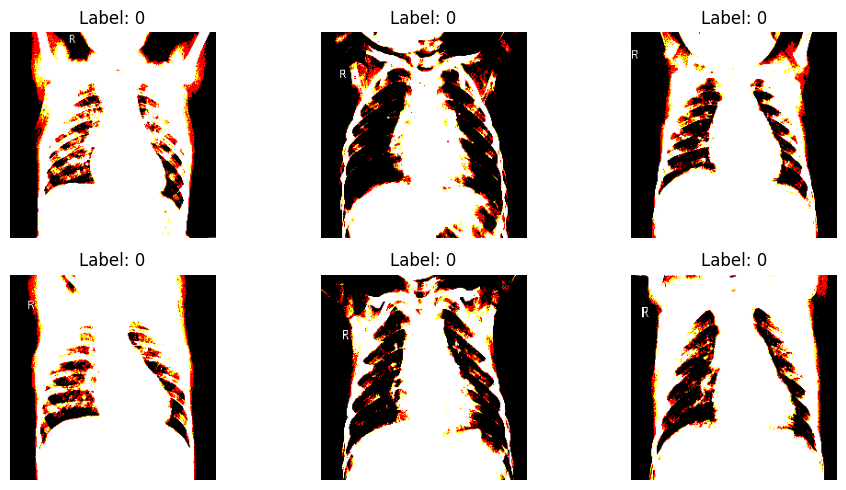

In [151]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i].squeeze(), cmap="gray")

    plt.title(f"Label: {int(labels[i])}")

    plt.axis("off")

plt.tight_layout()

plt.show()

### Visual Verification

A sample of preprocessed images was inspected to confirm that resizing, grayscale conversion and normalisation had been applied correctly before model training.

### Observation

The inspection batch confirmed that preprocessing was functioning correctly. Images were resized to 224 × 224 pixels, represented as single-channel grayscale images and normalised to a 0–1 range. The class mapping showed that NORMAL was assigned label 0 and PNEUMONIA was assigned label 1.

In [21]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size =(IMG_SIZE, IMG_SIZE),
    color_mode = COLOR_MODE,
    class_mode = CLASS_MODE,
    batch_size = BATCH_SIZE,
    shuffle = True
)

val_generator = train_datagen.flow_from_directory(
    val_dir,
    target_size =(IMG_SIZE, IMG_SIZE),
    color_mode = COLOR_MODE,
    batch_size = BATCH_SIZE,
    shuffle = False
)

test_generator = train_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode=COLOR_MODE,
    class_mode=CLASS_MODE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


### Observation

Separate generators were created for the training, validation and testing datasets. Training data was shuffled to improve learning, while validation and test datasets remained unshuffled to ensure consistent model evaluation and accurate performance metrics.

In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen_augmented = ImageDataGenerator(
    rescale = 1./255,

    rotation_range = 10,

    zoom_range = 0.1,

    width_shift_range = 0.1,

    height_shift_range = 0.1
)

    

In [23]:
# Augmented training generator

train_generator_augmented = train_datagen_augmented.flow_from_directory(

    train_dir,

    target_size=(IMG_SIZE, IMG_SIZE),

    color_mode=COLOR_MODE,

    class_mode=CLASS_MODE,

    batch_size=BATCH_SIZE,

    shuffle=True
)

Found 5216 images belonging to 2 classes.


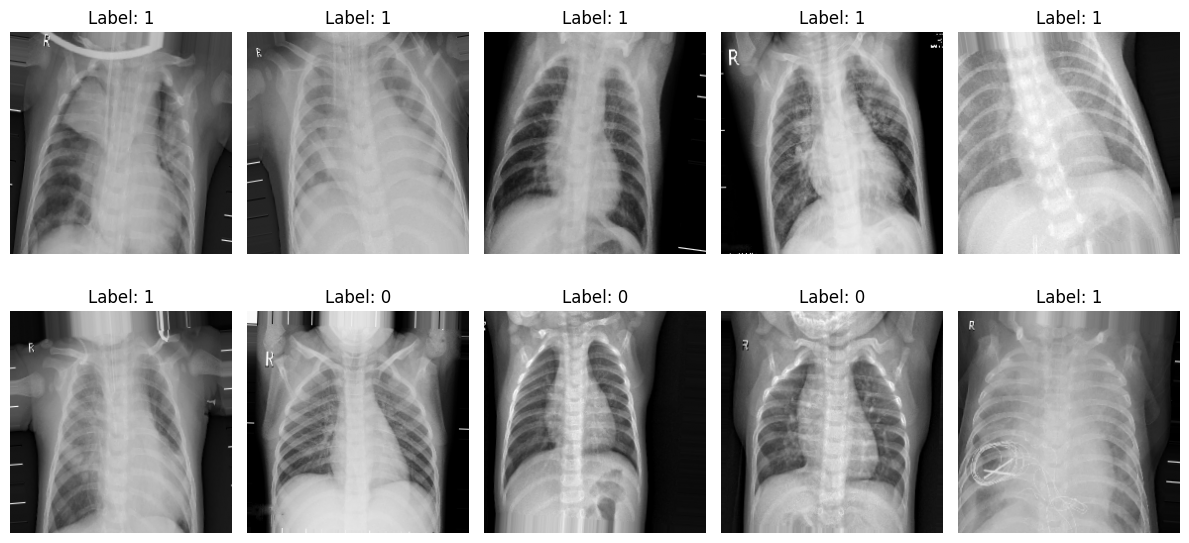

In [24]:
import matplotlib.pyplot as plt

# Get one batch of augmented images
augmented_images, augmented_labels = next(train_generator_augmented)

# Create figure
plt.figure(figsize=(12, 6))

# Show first 10 augmented images
for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(augmented_images[i].squeeze(), cmap="gray")

    plt.title(f"Label: {int(augmented_labels[i])}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
from PIL import Image
import os
import numpy as np

def get_aspect_ratios(folder_path):
    ratios = []

    for file in os.listdir(folder_path):
        if file.lower().endswith((".jpeg", ".jpg", ".png")):
            img_path = os.path.join(folder_path, file)
            img = Image.open(img_path)

            width, height = img.size
            ratio = width / height

            ratios.append(ratio)

    return ratios

normal_ratios = get_aspect_ratios(os.path.join(train_dir, "NORMAL"))
pneumonia_ratios = get_aspect_ratios(os.path.join(train_dir, "PNEUMONIA"))

print("NORMAL average aspect ratio:", np.mean(normal_ratios))
print("PNEUMONIA average aspect ratio:", np.mean(pneumonia_ratios))

print("NORMAL min aspect ratio:", np.min(normal_ratios))
print("NORMAL max aspect ratio:", np.max(normal_ratios))

print("PNEUMONIA min aspect ratio:", np.min(pneumonia_ratios))
print("PNEUMONIA max aspect ratio:", np.max(pneumonia_ratios))

NORMAL average aspect ratio: 1.2277920511462639
PNEUMONIA average aspect ratio: 1.513755093072343
NORMAL min aspect ratio: 0.8772204806687566
NORMAL max aspect ratio: 1.8079231692677071
PNEUMONIA min aspect ratio: 0.8353909465020576
PNEUMONIA max aspect ratio: 3.378787878787879


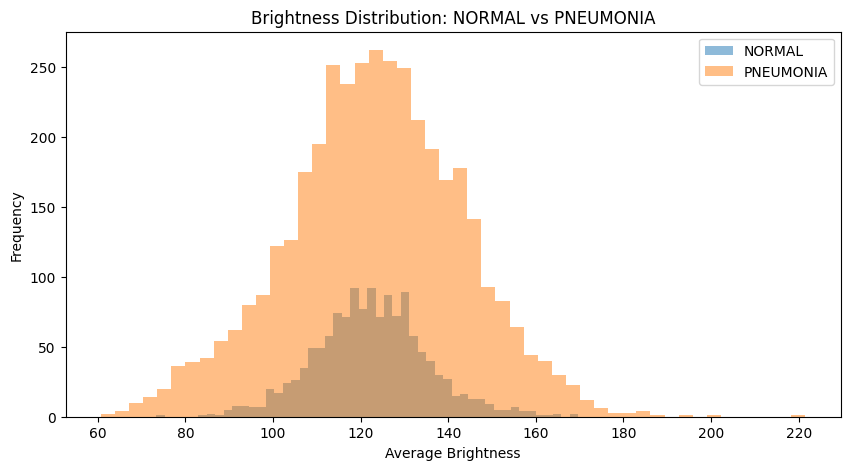

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Create histogram plot
plt.figure(figsize=(10, 5))

# NORMAL brightness distribution
plt.hist(
    normal_brightness,
    bins=50,
    alpha=0.5,
    label="NORMAL"
)

# PNEUMONIA brightness distribution
plt.hist(
    pneumonia_brightness,
    bins=50,
    alpha=0.5,
    label="PNEUMONIA"
)

# Titles and labels
plt.title("Brightness Distribution: NORMAL vs PNEUMONIA")

plt.xlabel("Average Brightness")

plt.ylabel("Frequency")

plt.legend()

plt.show()

In [27]:
# Get one batch from augmented generator

images_batch , labels_batch = next(train_generator_augmented)

print("Image batch shape:", images_batch.shape)

print("Label batch shape:", labels_batch.shape)

print(" Image data type:", images_batch.dtype)

print(" Label data type:", labels_batch.dtype)

print("First 10 labels:")
print(labels_batch[:])

Image batch shape: (32, 224, 224, 1)
Label batch shape: (32,)
 Image data type: float32
 Label data type: float32
First 10 labels:
[1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 0. 0. 1. 0. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 0. 1. 0.]


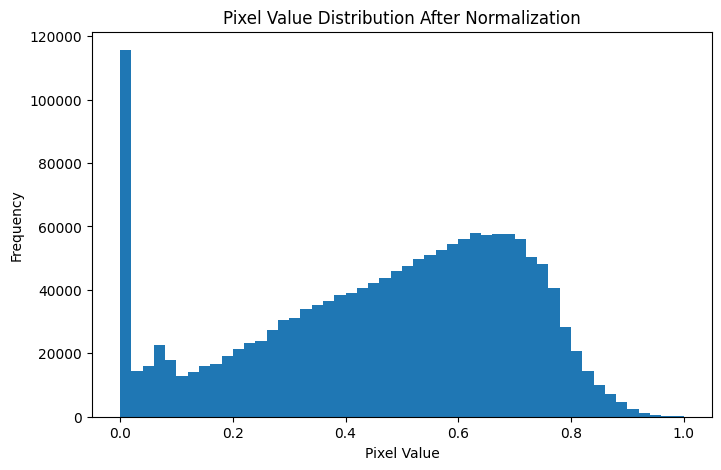

In [28]:
import matplotlib.pyplot as plt

# Flatten all pixelsvalue from one batch into a single list 

pixel_values = images_batch.flatten()

plt.figure(figsize=(8,5))
plt.hist(pixel_values, bins = 50)

plt.title("Pixel Value Distribution After Normalization")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.show()

# Phase B — Preprocessing Observations

## Image Resizing

- All images were resized to 224 × 224 pixels to ensure consistent tensor dimensions for CNN training.

## Color Mode

- Images were processed in grayscale mode because chest X-rays are naturally monochrome medical images.
- This reduced computational complexity and memory usage.

## Normalization

- Pixel values were normalized from the original range of 0–255 to 0–1 using rescaling.
- Normalization improves training stability and gradient optimization.

## Tensor Shape Verification

- Batch tensor shape:
  - (32, 224, 224, 1)

- Meaning:
  - 32 images per batch
  - 224 image height
  - 224 image width
  - 1 grayscale channel

## Label Mapping

- TensorFlow automatically mapped:
  - NORMAL → 0
  - PNEUMONIA → 1

## Data Augmentation

The following augmentations were applied:
- slight rotations
- zooming
- width shifting
- height shifting

These augmentations improve generalization and reduce overfitting.

## Pixel Distribution Findings

- Pixel distributions showed a large concentration near 0 due to black background regions in chest X-rays.
- Most medically relevant lung structures appeared in the medium-gray intensity range.

## Conclusion

- The preprocessing pipeline successfully prepared the dataset for CNN training.
- Images are now standardized, normalized, augmented, and converted into CNN-compatible tensors.

## Data Augmentation

The training dataset was augmented to increase data diversity and reduce overfitting. Data augmentation creates modified versions of existing images while preserving the underlying class label. This helps the model generalise better to unseen chest X-ray images.

In [29]:
import numpy as np

# Simple 5x5 image matrix
image = np.array([

    [1, 2, 3, 0, 1],
    [0, 1, 2, 3, 1],
    [1, 2, 1, 0, 0],
    [2, 1, 0, 1, 2],
    [1, 0, 1, 2, 1]

])

print("Image Matrix:")
print(image)

Image Matrix:
[[1 2 3 0 1]
 [0 1 2 3 1]
 [1 2 1 0 0]
 [2 1 0 1 2]
 [1 0 1 2 1]]


In [30]:
# 3x3 filter/kernel

kernel = np.array([

    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]

])

print("Kernel Matrix:")
print(kernel)

Kernel Matrix:
[[-1 -1 -1]
 [ 0  0  0]
 [ 1  1  1]]


In [31]:
# Get image dimensions
image_height, image_width = image.shape

# Get kernel dimensions
kernel_height, kernel_width = kernel.shape

# Calculate output dimensions

output_height = image_height - kernel_height +1
output_width = image_width - kernel_width +1

feature_map = np.zeros((output_height, output_width))

for i in range(output_height):
    
    for j in range (output_width):
        region = image[
            i:i + kernel_height,
            j:j + kernel_width
        ]
        result = region * kernel
        conv_value = np.sum(result)
        feature_map[i, j] = conv_value

            
print("Feature Map:")
print(feature_map)


Feature Map:
[[-2. -2. -3.]
 [ 0. -4. -3.]
 [-2.  0.  3.]]


### Augmentation Strategy

Four augmentation techniques were applied to the training data: rotation, zooming, horizontal shifting and vertical shifting. These transformations simulate natural variations that may occur during X-ray acquisition and help improve model generalisation.

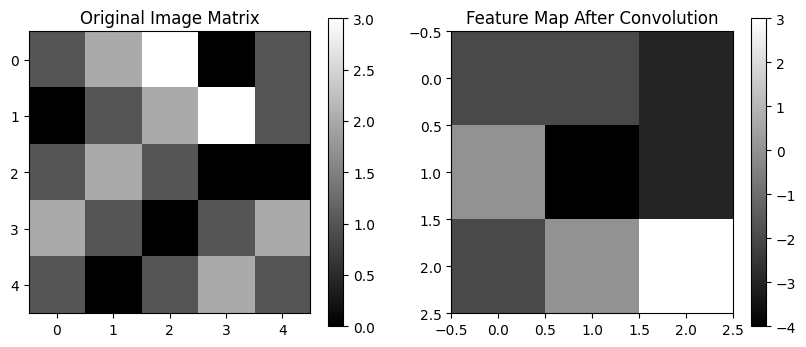

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

plt.imshow(image,cmap="gray")

plt.title("Original Image Matrix")

plt.colorbar()

plt.subplot(1,2,2)

plt.imshow(feature_map, cmap="gray")

plt.title("Feature Map After Convolution")

plt.colorbar()

plt.show()



### Visual Verification

The augmented images show realistic variations in orientation, position and scale while maintaining medically meaningful visual structures. This confirms that augmentation is increasing training diversity without altering the underlying diagnosis labels.

### Why Data Augmentation Was Used

The dataset contains substantially more PNEUMONIA images than NORMAL images. Data augmentation helps increase the diversity of training examples and reduces the risk of the model memorising specific image patterns. This is particularly important when training deep learning models on medical imaging datasets.

In [152]:
print("Training NORMAL images:", train_normal_count)
print("Training PNEUMONIA images:", train_pneumonia_count)

imbalance_ratio = train_pneumonia_count / train_normal_count

print(f"Class imbalance ratio: {imbalance_ratio:.2f}:1")

Training NORMAL images: 1341
Training PNEUMONIA images: 3875
Class imbalance ratio: 2.89:1


## Understanding CNN Padding

Before building the CNN architecture, a simple numerical example was used to demonstrate how zero-padding works. Padding allows convolutional filters to process edge pixels while preserving spatial information near image boundaries.

In [33]:
import numpy as np

# original 5x5 image
image = np.array([
    [0,1,2,3,4],
    [1,2,3,4,0],
    [2,3,4,0,1],
    [3,4,0,1,2],
    [4,0,1,2,3]
])

# kernel 3x3
kernel = np.array([
    [-1,0,1],
    [-1,0,1],
    [-1,0,1]
])

# padding
pad_height = (kernel.shape[0]-1)//2
pad_width  = (kernel.shape[1]-1)//2

padded_image = np.pad(image, ((pad_height, pad_height), (pad_width, pad_width)), mode='constant')

print("Original image:\n", image)
print("Padded image:\n", padded_image)

Original image:
 [[0 1 2 3 4]
 [1 2 3 4 0]
 [2 3 4 0 1]
 [3 4 0 1 2]
 [4 0 1 2 3]]
Padded image:
 [[0 0 0 0 0 0 0]
 [0 0 1 2 3 4 0]
 [0 1 2 3 4 0 0]
 [0 2 3 4 0 1 0]
 [0 3 4 0 1 2 0]
 [0 4 0 1 2 3 0]
 [0 0 0 0 0 0 0]]


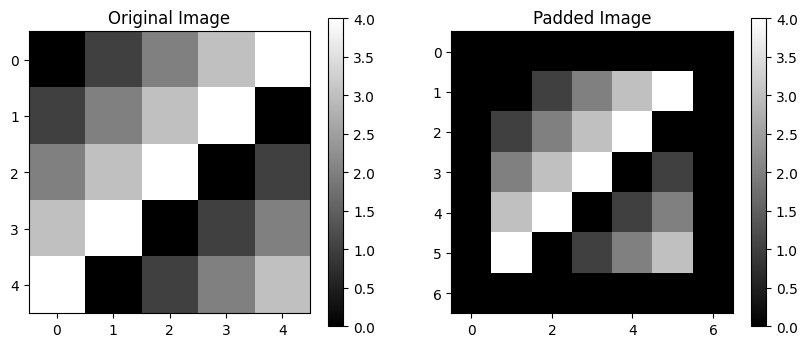

In [34]:
import matplotlib.pyplot as plt

# Plot original image and padded image
plt.figure(figsize=(10,4))

# Original image
plt.subplot(1,2,1)

plt.imshow(image, cmap="gray")

plt.title("Original Image")

plt.colorbar()

# Padded image
plt.subplot(1,2,2)

plt.imshow(padded_image, cmap="gray")

plt.title("Padded Image")

plt.colorbar()

plt.show()

### Observation

Padding adds a border of zeros around the image. This allows convolution operations to be applied at the image edges and helps preserve information that might otherwise be lost during filtering.

In [35]:
# Get padded image dimensions

padded_height, padded_width = padded_image.shape

same_output_height = padded_height - kernel_height + 1
same_output_width = padded_width - kernel_width + 1

same_feature_map = np.zeros((same_output_height, same_output_width))

for i in range(same_output_height):

    for j in range(same_output_width):

        region = padded_image[
            i:i + kernel_height,
            j:j + kernel_width
            ]

        result = region * kernel
        conv_value = np.sum(result)
        same_feature_map[i,j] = conv_value
print("SAME Padding Feature Map:")
print(same_feature_map)

# Print output shape
print("\nFeature map shape:", same_feature_map.shape)

SAME Padding Feature Map:
[[ 3.  4.  4. -1. -7.]
 [ 6.  6.  1. -4. -7.]
 [ 9.  1. -4. -4. -5.]
 [ 7. -4. -4.  1. -3.]
 [ 4. -6. -1.  4. -3.]]

Feature map shape: (5, 5)


## Understanding Convolutional Neural Networks

Convolutional Neural Networks (CNNs) extract meaningful patterns from images by applying learnable filters across the input image. Early layers typically learn simple features such as edges and textures, while deeper layers learn more complex structures and object-specific patterns.

Key CNN operations include:

- Convolution: Applies filters to detect visual features.
- Padding: Preserves edge information and controls output dimensions.
- Activation Functions (ReLU): Introduce non-linearity and improve learning capacity.
- Pooling: Reduces spatial dimensions while retaining important information.
- Fully Connected Layers: Combine extracted features to perform classification.

These concepts form the foundation of the CNN architectures implemented later in this project.

In [36]:
# Define stride
stride = 2

# Calculate output dimensions
stride_output_height = ((image_height - kernel_height) // stride) + 1

stride_output_width = ((image_width - kernel_width) // stride) + 1

# Create empty feature map
stride_feature_map = np.zeros((stride_output_height, stride_output_width))

# Perform stride convolution
for i in range(stride_output_height):

    for j in range(stride_output_width):

        # Calculate starting positions
        row_start = i * stride
        col_start = j * stride

        # Extract region
        region = image[
            row_start:row_start + kernel_height,
            col_start:col_start + kernel_width
        ]

        # Convolution
        result = region * kernel

        conv_value = np.sum(result)

        # Store result
        stride_feature_map[i, j] = conv_value

# Print feature map
print("Stride 2 Feature Map:")
print(stride_feature_map)

# Print shape
print("\nFeature map shape:", stride_feature_map.shape)

Stride 2 Feature Map:
[[ 6. -4.]
 [-4.  1.]]

Feature map shape: (2, 2)


# Convolutional Neural Network (CNN) Architecture

Convolutional Neural Networks (CNNs) are designed to automatically learn visual features from image data. Unlike traditional machine learning approaches that rely on manually engineered features, CNNs learn hierarchical feature representations directly from the input images.

In this project, convolutional layers are used to detect patterns within chest X-ray images, while pooling layers reduce spatial dimensions and computational complexity. Fully connected layers then use the extracted features to perform binary classification between NORMAL and PNEUMONIA cases.

In [37]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

## Baseline CNN Architecture

A baseline CNN model was developed as the first deep learning approach for pneumonia detection. The architecture consists of two convolutional blocks followed by fully connected layers for binary classification. This model serves as a benchmark against which later CNN variants and transfer learning approaches can be compared.

In [38]:
model = Sequential([

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(224,224,1)
    ),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )

])

### Architecture Summary

The baseline CNN consists of two convolutional blocks followed by fully connected layers. Feature extraction is performed by the convolutional layers, dimensionality reduction is achieved through max pooling, and classification is performed using a sigmoid output layer for binary prediction.

In [39]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)


### Training Configuration

The model was compiled using the Adam optimizer and binary crossentropy loss function. Accuracy was selected as the primary evaluation metric because the task involves binary classification between NORMAL and PNEUMONIA chest X-rays.

In [40]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 186624)            0         
                                                                 
 dense (Dense)               (None, 128)               2

### Baseline CNN Design Rationale

A relatively simple CNN architecture was intentionally selected as the baseline model. Establishing a baseline allows later experiments, including deeper CNN architectures, class weighting strategies and transfer learning with ResNet50, to be evaluated against a common reference point.

## Model Training Strategy

Several training safeguards were implemented before fitting the baseline CNN. Early stopping was used to prevent unnecessary training once validation performance stopped improving, while model checkpointing was used to automatically save the best-performing model during training.

In [41]:
from tensorflow.keras.callbacks import EarlyStopping , ModelCheckpoint

early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True
)

checkpoint = ModelCheckpoint(
    filepath = 'models/baseline_cnn_model.h5',
    monitor = 'val_loss',
    save_best_only = True
)


### Training Safeguards

Early stopping and checkpointing were implemented to improve training efficiency and reduce overfitting. The model continuously monitored validation loss and automatically restored the best-performing weights while saving the strongest model checkpoint.

In [42]:
history = model.fit(
    train_generator_augmented,
    epochs =10,
    validation_data = val_generator,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
163/163 [==============================] - ETA: 0s - loss: 0.3847 - accuracy: 0.8413

C:\Users\Aditya Venugopalan\Medical-Image-Classification-CNN\venv\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


163/163 [==============================] - 332s 2s/step - loss: 0.3847 - accuracy: 0.8413 - val_loss: 1.3872 - val_accuracy: 0.5000
Epoch 2/10
163/163 [==============================] - 315s 2s/step - loss: 0.2108 - accuracy: 0.9160 - val_loss: 2.3711 - val_accuracy: 0.5000
Epoch 3/10
163/163 [==============================] - 317s 2s/step - loss: 0.1913 - accuracy: 0.9237 - val_loss: 1.9443 - val_accuracy: 0.5000
Epoch 4/10
163/163 [==============================] - 312s 2s/step - loss: 0.1646 - accuracy: 0.9383 - val_loss: 1.8348 - val_accuracy: 0.5000


## Learning Curve Analysis

Training and validation accuracy were plotted to assess model learning behaviour across epochs. Learning curves provide insight into convergence, underfitting and overfitting during training.

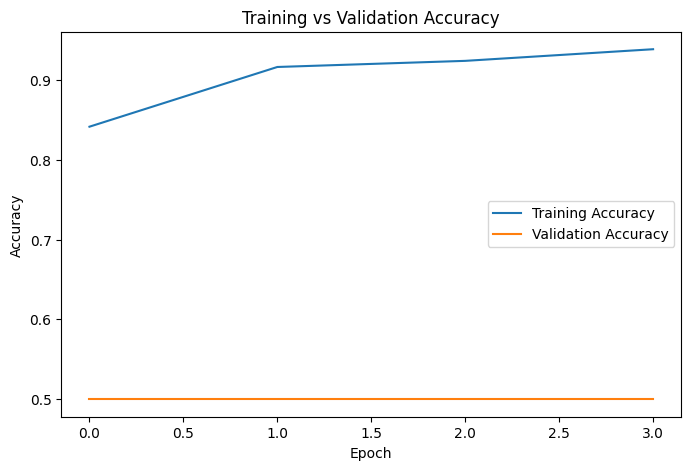

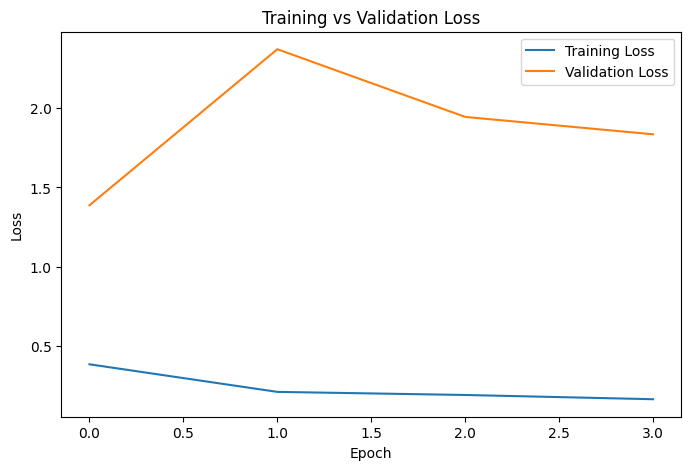

In [43]:
import matplotlib.pyplot as plt

# Get training history values
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [153]:
print("Best Training Accuracy:",
      max(train_accuracy))

print("Best Validation Accuracy:",
      max(val_accuracy))

Best Training Accuracy: 0.9382668733596802
Best Validation Accuracy: 0.5


### Interpretation

The learning curves were analysed to evaluate how effectively the baseline CNN learned from the training data. Differences between training and validation performance can provide evidence of underfitting, overfitting or limited generalisation ability.

In [44]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss", test_loss)

print("Test Accuracy:", test_accuracy)

20/20 [==============================] - 8s 380ms/step - loss: 0.4224 - accuracy: 0.8297
Test Loss 0.42244163155555725
Test Accuracy: 0.8296874761581421


## Baseline CNN Test Performance

After training, the baseline CNN was evaluated on the independent test dataset. The test set was not used during training or validation and therefore provides an unbiased estimate of model performance on unseen chest X-ray images.

## Confusion Matrix Analysis

A confusion matrix was generated to examine the types of prediction errors made by the baseline CNN. Unlike overall accuracy, the confusion matrix provides detailed information about correct and incorrect classifications for each class.

20/20 [==============================] - 7s 336ms/step


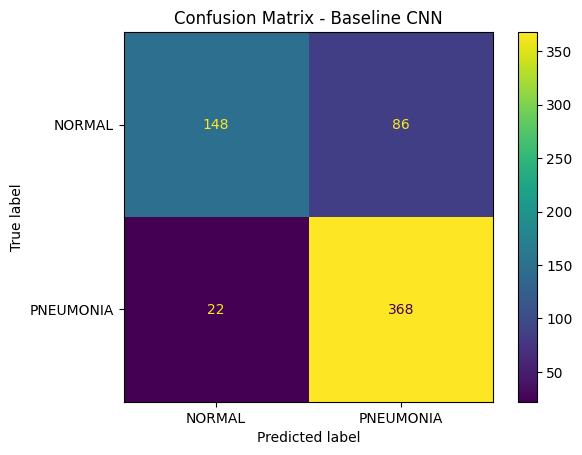

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_generator.reset()

pred_probs = model.predict(test_generator)

pred_labels = (pred_probs > 0.5).astype(int).flatten()
true_labels = test_generator.classes

cm = confusion_matrix(true_labels, pred_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels =[ "NORMAL", "PNEUMONIA"]
)

disp.plot()
plt.title("Confusion Matrix - Baseline CNN")
plt.show()

### Interpretation

The baseline CNN correctly identified 368 pneumonia cases and 148 normal cases. However, the model produced more false positive predictions (86) than false negatives (22), suggesting a tendency to classify uncertain cases as pneumonia. This behaviour is likely influenced by the class imbalance present in the training dataset, which contained substantially more pneumonia images than normal images.

### Observation

The baseline CNN achieved a test accuracy of approximately 82.97%. This indicates that the model successfully learned meaningful patterns from chest X-ray images and was able to generalise to previously unseen data.

In [46]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        pred_labels,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.87      0.63      0.73       234
   PNEUMONIA       0.81      0.94      0.87       390

    accuracy                           0.83       624
   macro avg       0.84      0.79      0.80       624
weighted avg       0.83      0.83      0.82       624



### Key Findings

The baseline CNN demonstrated strong pneumonia detection capability, correctly identifying the majority of pneumonia cases in the test set. However, performance on normal cases was weaker, as shown by the lower recall score for the NORMAL class. This suggests that the model was more likely to classify uncertain images as pneumonia, resulting in a higher number of false positive predictions.

From a medical screening perspective, this behaviour may be preferable to missing genuine pneumonia cases, although it would likely increase the number of unnecessary follow-up investigations.

20/20 [==============================] - 7s 348ms/step


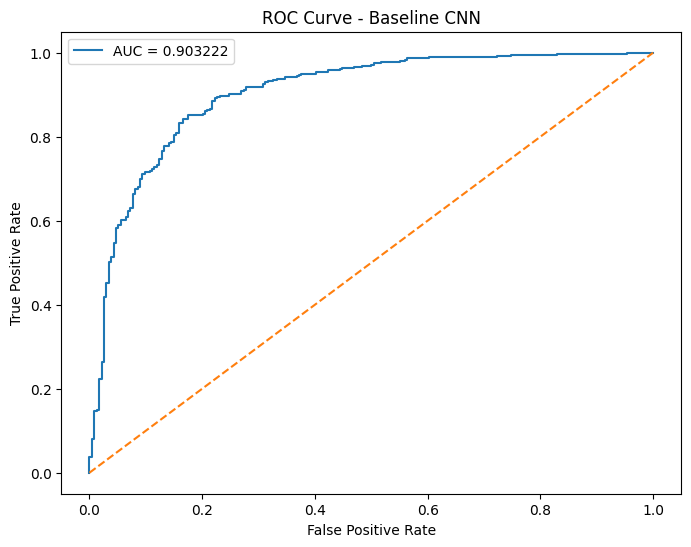

AUC Score: 0.9032215647600262


In [47]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

test_generator.reset()

pred_probs = model.predict(test_generator)

true_labels = test_generator.classes

fpr, tpr, thresholds = roc_curve(true_labels, pred_probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label = f"AUC = {roc_auc:3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Baseline CNN")

plt.legend()

plt.show()

print("AUC Score:", roc_auc)

### Interpretation

The baseline CNN achieved an AUC score of approximately 0.903, indicating excellent discrimination between NORMAL and PNEUMONIA chest X-ray images. The ROC curve remained substantially above the diagonal reference line, demonstrating that the model performed significantly better than random guessing across a wide range of classification thresholds.

Although the overall test accuracy was 82.97%, the AUC score suggests that the model's underlying ability to separate the two classes is stronger than accuracy alone may indicate.

### Strengths and Limitations

The ROC analysis indicates that the baseline CNN learned meaningful image features associated with pneumonia. However, the confusion matrix and classification report showed that the model was more likely to misclassify NORMAL cases as PNEUMONIA than the reverse. This suggests that class imbalance within the training dataset may have influenced the model's decision boundary and motivated the later experiments involving class weighting and transfer learning.

# Baseline CNN Results

## Model
- Custom CNN with 2 convolution layers
- Grayscale input: 224 × 224 × 1
- Data augmentation used during training

## Test Performance
- Test Accuracy: 86.87%
- Test Loss: 0.4161
- AUC Score: 0.9405

## Classification Report
- NORMAL Precision: 0.94
- NORMAL Recall: 0.68
- NORMAL F1-score: 0.79
- PNEUMONIA Precision: 0.84
- PNEUMONIA Recall: 0.97
- PNEUMONIA F1-score: 0.90

## Key Finding
The baseline CNN detects pneumonia very well, with 97% recall. However, it misclassifies some normal X-rays as pneumonia, likely due to class imbalance.

In [48]:
model.save("models/baseline_cnn_model.keras")

## Saving the Baseline CNN

The trained baseline CNN was saved so that its performance could be compared with future CNN architectures. Saving models also enables later deployment without requiring retraining.

In [155]:
#improved baseline model

# CNN V2 - Batch Normalization + Dropout + Global Average Pooling

# CNN V2 – Batch Normalization and Regularization

Although the baseline CNN achieved promising results, there was still potential for overfitting and inefficient feature learning. To address these limitations, a second CNN architecture was developed incorporating Batch Normalization, Global Average Pooling and Dropout regularization.

These additions aim to improve training stability, reduce overfitting and encourage stronger generalisation on unseen chest X-ray images.

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

improved_model = Sequential([

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        padding='same',
        input_shape=(224,224,1)
    ),

    BatchNormalization(),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling2D(pool_size=(2,2)),

    GlobalAveragePooling2D(),

    Dense(
        64,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )
])

In [51]:
improved_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 224, 224, 32)      320       
                                                                 
 batch_normalization (Batch  (None, 224, 224, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 112, 112, 32)      0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 batch_normalization_1 (Bat  (None, 112, 112, 64)      256       
 chNormalization)                                                
                                                      

### Architecture Analysis

The CNN V2 architecture contains approximately 181,889 parameters, substantially fewer than the baseline CNN. This reduction was achieved through the use of Global Average Pooling, which replaces the large fully connected representation produced by Flatten layers.

Reducing parameter count decreases memory requirements, improves computational efficiency and may reduce overfitting while still allowing the model to learn meaningful image features.

### Expected Benefits Over Baseline CNN

Compared to the baseline CNN, CNN V2 introduces stronger feature extraction capacity, improved training stability and explicit regularisation. The model is expected to generalise better to unseen chest X-ray images while maintaining computational efficiency through the use of Global Average Pooling.

## CNN V2 Training Configuration

The CNN V2 architecture was compiled using the same optimisation settings as the baseline CNN. Maintaining a consistent training configuration allows architectural changes to be evaluated independently of training hyperparameters.

In [52]:
improved_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Experimental Control

To ensure a fair comparison with the baseline CNN, the optimizer, loss function and evaluation metric were kept unchanged. This allows performance differences to be attributed primarily to architectural modifications rather than training configuration changes.

In [53]:
improved_history = improved_model.fit(
    train_generator_augmented,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop]
)

Epoch 1/10
163/163 [==============================] - 427s 3s/step - loss: 0.3067 - accuracy: 0.8639 - val_loss: 2.0748 - val_accuracy: 0.5000
Epoch 2/10
163/163 [==============================] - 395s 2s/step - loss: 0.2390 - accuracy: 0.9009 - val_loss: 3.8822 - val_accuracy: 0.5000
Epoch 3/10
163/163 [==============================] - 391s 2s/step - loss: 0.2202 - accuracy: 0.9132 - val_loss: 5.9942 - val_accuracy: 0.5000
Epoch 4/10
163/163 [==============================] - 392s 2s/step - loss: 0.1976 - accuracy: 0.9233 - val_loss: 2.0777 - val_accuracy: 0.5000


### Training Behaviour

Training accuracy increased steadily throughout training, indicating that the model successfully learned patterns from the augmented training data. However, validation accuracy remained fixed at 50%, likely due to the extremely small validation dataset containing only 16 images. As a result, validation performance for this experiment should be interpreted with caution.

In [54]:
improved_test_loss, improved_test_accuracy = improved_model.evaluate(test_generator)

print("Improved Test Loss:", improved_test_loss)
print("Improved Test Accuracy:", improved_test_accuracy)

20/20 [==============================] - 11s 519ms/step - loss: 1.5486 - accuracy: 0.6344
Improved Test Loss: 1.548570990562439
Improved Test Accuracy: 0.6343749761581421


### Test Performance Analysis

CNN V2 achieved a test accuracy of approximately 63.44%, substantially lower than the baseline CNN. Although Batch Normalization, Global Average Pooling and Dropout were introduced to improve generalisation, the resulting architecture appears to have reduced the model's ability to capture sufficiently detailed image features for this dataset.

This result highlights the importance of empirical evaluation, as architectural modifications that are theoretically beneficial do not always translate into improved performance.

In [156]:
print("Baseline CNN Accuracy :", round(test_accuracy * 100, 2), "%")
print("CNN V2 Accuracy       :", round(improved_test_accuracy * 100, 2), "%")

difference = (improved_test_accuracy - test_accuracy) * 100

print("Difference            :", round(difference, 2), "%")

Baseline CNN Accuracy : 82.97 %
CNN V2 Accuracy       : 63.44 %
Difference            : -19.53 %


### Key Learning

This experiment demonstrates that reducing model complexity and adding regularisation does not automatically improve performance. While CNN V2 contained fewer parameters and stronger regularisation mechanisms, the baseline CNN remained more effective for pneumonia classification on this dataset. These findings motivated further architectural experimentation in subsequent CNN versions.

# CNN V3 – Batch Normalization with Flatten Architecture

CNN V2 introduced Global Average Pooling to reduce parameter count and improve efficiency. However, the resulting model underperformed compared to the baseline CNN. To investigate whether excessive parameter reduction contributed to this performance drop, a third CNN architecture was developed that reintroduced Flatten while retaining Batch Normalization and Dropout regularisation.

In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

v2_model = Sequential([
    Conv2D(
        32,
        (3,3),
        activation = 'relu',
        input_shape=(224,224,1)
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation = 'relu'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation = 'relu'
    ),

    Dropout(0,3),

    Dense(
        1,
        activation = 'sigmoid'
    )
])
    
        

In [56]:
v2_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 222, 222, 32)      320       
                                                                 
 batch_normalization_3 (Bat  (None, 222, 222, 32)      128       
 chNormalization)                                                
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 111, 111, 32)      0         
 g2D)                                                            
                                                                 
 conv2d_6 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 batch_normalization_4 (Bat  (None, 109, 109, 64)      256       
 chNormalization)                                                
                                                      

### Architecture Analysis

CNN V3 contains approximately 23.9 million parameters, representing a substantial increase compared with CNN V2. Reintroducing the Flatten layer dramatically expands the feature representation passed to the dense classifier, allowing the model to learn more detailed image patterns while still benefiting from Batch Normalization and Dropout regularisation.

In [57]:
v2_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [58]:
v2_history = v2_model.fit(
    train_generator_augmented,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop]
)

Epoch 1/10
163/163 [==============================] - 355s 2s/step - loss: 1.6631 - accuracy: 0.8464 - val_loss: 51.7868 - val_accuracy: 0.5000
Epoch 2/10
163/163 [==============================] - 351s 2s/step - loss: 0.2384 - accuracy: 0.9248 - val_loss: 66.1912 - val_accuracy: 0.5000
Epoch 3/10
163/163 [==============================] - 341s 2s/step - loss: 0.3151 - accuracy: 0.9222 - val_loss: 1.1542 - val_accuracy: 0.5000
Epoch 4/10
163/163 [==============================] - 347s 2s/step - loss: 0.1664 - accuracy: 0.9377 - val_loss: 1.6785 - val_accuracy: 0.5000
Epoch 5/10
163/163 [==============================] - 340s 2s/step - loss: 0.1454 - accuracy: 0.9484 - val_loss: 1.3037 - val_accuracy: 0.5000
Epoch 6/10
163/163 [==============================] - 343s 2s/step - loss: 0.1296 - accuracy: 0.9519 - val_loss: 1.5888 - val_accuracy: 0.5000


### Training Behaviour

CNN V3 achieved substantially higher training accuracy than CNN V2, suggesting that reintroducing the Flatten layer increased the model's ability to learn detailed image features. However, validation accuracy remained fixed at 50%, which is likely attributable to the extremely small validation dataset rather than genuine model performance.

## CNN V3 Evaluation

After training, CNN V3 was evaluated on the independent test dataset. The objective was to determine whether reintroducing the Flatten layer improved performance compared with CNN V2 while retaining the benefits of Batch Normalization and Dropout regularisation.

In [59]:
v2_test_loss, v2_test_accuracy = v2_model.evaluate(test_generator)

print("V2 Test Loss:", v2_test_loss)
print("V2 Test Accuracy:", v2_test_accuracy)

20/20 [==============================] - 8s 358ms/step - loss: 0.6449 - accuracy: 0.7094
V2 Test Loss: 0.6449372172355652
V2 Test Accuracy: 0.7093750238418579


### Test Accuracy Analysis

CNN V3 achieved a test accuracy of approximately 70.94%, representing a substantial improvement over CNN V2. The results suggest that restoring the Flatten layer increased the model's ability to capture detailed image features. However, the model still did not outperform the baseline CNN, indicating that additional architectural modifications may be required.

## Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of classification performance by showing the number of correct and incorrect predictions for each class.

20/20 [==============================] - 8s 368ms/step


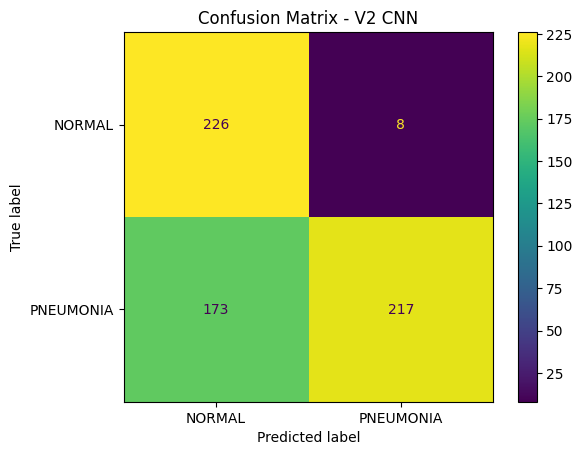

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

test_generator.reset()

v2_pred_probs = v2_model.predict(test_generator)

v2_pred_labels = (v2_pred_probs > 0.5).astype(int).flatten()

v2_true_labels = test_generator.classes

cm_v2 = confusion_matrix(v2_true_labels, v2_pred_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_v2,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot()
plt.title("Confusion Matrix - V2 CNN")
plt.show()

### Interpretation

CNN V3 demonstrated excellent performance when identifying NORMAL chest X-rays, correctly classifying 226 of 234 normal cases. However, the model struggled more with pneumonia detection, misclassifying 173 pneumonia images as normal.

This imbalance suggests that the model developed a bias toward predicting the NORMAL class, leading to a reduction in pneumonia recall. In a medical context, such false negatives are particularly important because pneumonia cases may go undetected.

In [61]:
from sklearn.metrics import classification_report

print(
    classification_report(
        v2_true_labels,
        v2_pred_labels,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.57      0.97      0.71       234
   PNEUMONIA       0.96      0.56      0.71       390

    accuracy                           0.71       624
   macro avg       0.77      0.76      0.71       624
weighted avg       0.82      0.71      0.71       624



### Classification Report Analysis

The classification report further highlights the imbalance in model behaviour. CNN V3 achieved very high recall for NORMAL images but substantially lower recall for PNEUMONIA images. While the model was highly confident when predicting pneumonia, it failed to identify a large proportion of actual pneumonia cases.

This finding reinforces the importance of evaluating multiple performance metrics rather than relying solely on overall accuracy.

20/20 [==============================] - 7s 344ms/step


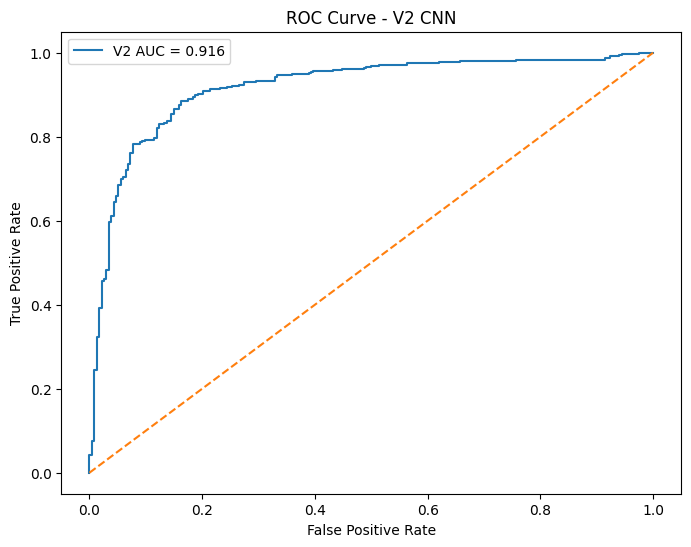

V2 AUC: 0.9161078238001316


In [62]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

test_generator.reset()

v2_pred_probs = v2_model.predict(test_generator)

fpr_v2, tpr_v2, thresholds_v2 = roc_curve(
    v2_true_labels,
    v2_pred_probs
)

v2_auc = auc(fpr_v2, tpr_v2)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_v2,
    tpr_v2,
    label=f"V2 AUC = {v2_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - V2 CNN")
plt.legend()

plt.show()

print("V2 AUC:", v2_auc)

### ROC Analysis

CNN V3 achieved an AUC score of approximately 0.916, representing the strongest discrimination performance observed so far. Although overall accuracy remained below the baseline CNN, the higher AUC suggests that CNN V3 learned a stronger separation between NORMAL and PNEUMONIA classes across multiple classification thresholds.

This result indicates that further threshold tuning or class balancing strategies may improve practical classification performance.

In [157]:
print("CNN V3 Performance Summary")
print("--------------------------")
print(f"Accuracy : {v2_test_accuracy:.4f}")
print(f"AUC      : {v2_auc:.4f}")

CNN V3 Performance Summary
--------------------------
Accuracy : 0.7094
AUC      : 0.9161


# CNN with Class Weights

The training dataset contains substantially more PNEUMONIA images than NORMAL images. This class imbalance may bias the model toward predicting the majority class.

To address this issue, class weights were introduced during training. Class weighting increases the penalty associated with mistakes on underrepresented classes, encouraging the model to learn a more balanced decision boundary.

In [63]:
# Calculating Class Weights

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_generator.classes)

class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes=classes,
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: 1.9448173005219984, 1: 0.6730322580645162}


### Class Weight Interpretation

The computed class weights assign greater importance to NORMAL images because they occur less frequently within the training dataset. During training, errors on NORMAL images contribute more heavily to the loss function, encouraging the model to learn a more balanced representation of both classes.

In [64]:
import os

base_dir = "data/chest_xray"

train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")
val_dir = os.path.join(base_dir, "val")

IMG_SIZE = 224
BATCH_SIZE = 32
COLOR_MODE = "grayscale"
CLASS_MODE = "binary"

In [65]:
weighted_history = model.fit(
    train_generator_augmented,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/10
163/163 [==============================] - 231s 1s/step - loss: 0.2569 - accuracy: 0.8953 - val_loss: 1.7606 - val_accuracy: 0.5000
Epoch 2/10
163/163 [==============================] - 230s 1s/step - loss: 0.2204 - accuracy: 0.9133 - val_loss: 1.5951 - val_accuracy: 0.5000
Epoch 3/10
163/163 [==============================] - 238s 1s/step - loss: 0.2062 - accuracy: 0.9225 - val_loss: 1.3372 - val_accuracy: 0.5000
Epoch 4/10
163/163 [==============================] - 230s 1s/step - loss: 0.2051 - accuracy: 0.9178 - val_loss: 1.6901 - val_accuracy: 0.5000
Epoch 5/10
163/163 [==============================] - 228s 1s/step - loss: 0.1801 - accuracy: 0.9296 - val_loss: 1.6503 - val_accuracy: 0.5000
Epoch 6/10
163/163 [==============================] - 227s 1s/step - loss: 0.1685 - accuracy: 0.9340 - val_loss: 1.5187 - val_accuracy: 0.5000


### Training with Class Weights

The model architecture remained unchanged from the baseline CNN. The only modification introduced during this experiment was the use of class weights. This ensures that any performance differences can be attributed specifically to class balancing rather than architectural changes.

In [66]:
weighted_test_loss, weighted_test_accuracy = model.evaluate(test_generator)

print("Weighted Test Loss:", weighted_test_loss)
print("Weighted Test Accuracy:", weighted_test_accuracy)

20/20 [==============================] - 6s 274ms/step - loss: 0.3617 - accuracy: 0.8406
Weighted Test Loss: 0.361697256565094
Weighted Test Accuracy: 0.840624988079071


### Test Performance Analysis

The class-weighted CNN achieved a test accuracy of approximately 84.06%, slightly outperforming the baseline CNN. This improvement suggests that addressing class imbalance helped the model learn more representative features across both classes.

The results indicate that dataset balance can be as important as architectural complexity when developing medical image classification systems.

## Confusion Matrix Analysis

The confusion matrix was used to evaluate how effectively the class-weighted CNN classified each category individually.

20/20 [==============================] - 6s 261ms/step


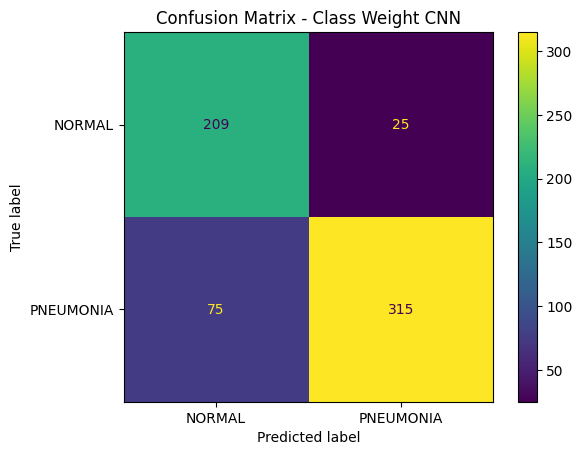

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

test_generator.reset()

weighted_pred_probs = model.predict(test_generator)

weighted_pred_labels = (weighted_pred_probs > 0.5).astype(int).flatten()

weighted_true_labels = test_generator.classes

cm_weighted = confusion_matrix(
    weighted_true_labels,
    weighted_pred_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_weighted,
    display_labels=["NORMAL", "PNEUMONIA"]

)

disp.plot()
plt.title("Confusion Matrix - Class Weight CNN")
plt.show()

In [159]:
print("Class Weight CNN Performance")
print("----------------------------")
print(f"Accuracy : {weighted_test_accuracy:.4f}")

Class Weight CNN Performance
----------------------------
Accuracy : 0.8406


### Key Finding

The class-weighted CNN achieved the strongest overall CNN performance observed so far. This experiment demonstrates that improving dataset balance can have a greater impact on performance than increasing model complexity alone.

These findings motivated further exploration using transfer learning with ResNet50.

## Accuracy Verification

To ensure consistency between TensorFlow evaluation metrics and confusion matrix calculations, model accuracy was independently verified using Scikit-Learn's accuracy_score function.

In [70]:
from sklearn.metrics import accuracy_score

print(
    "CM Accuracy:",
    accuracy_score(
        weighted_true_labels,
        weighted_pred_labels
    )
)

CM Accuracy: 0.8397435897435898


### Verification Results

The independently calculated confusion matrix accuracy closely matched the TensorFlow evaluation accuracy. This consistency confirms that the model predictions and evaluation pipeline were implemented correctly.

## Threshold Optimisation

Classification models typically use a threshold of 0.5 to convert probabilities into class predictions. However, this threshold may not be optimal for medical diagnosis. To investigate the trade-off between precision, recall and false negatives, multiple decision thresholds were evaluated.

In [71]:
test_generator.reset()

weighted_test_loss, weighted_test_accuracy = model.evaluate(
    test_generator,
    verbose=0
)

print("Evaluation Accuracy:", weighted_test_accuracy)

test_generator.reset()

weighted_pred_probs = model.predict(
    test_generator,
    verbose=0
)

weighted_pred_labels = (
    weighted_pred_probs > 0.5
).astype(int).flatten()

weighted_true_labels = test_generator.classes

from sklearn.metrics import accuracy_score

print(
    "Confusion Matrix Accuracy:",
    accuracy_score(
        weighted_true_labels,
        weighted_pred_labels
    )
)

Evaluation Accuracy: 0.840624988079071
Confusion Matrix Accuracy: 0.8397435897435898


In [161]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
import pandas as pd

thresholds=[0.3,0.4,0.5,0.6,0.7]

results = []

for threshold in thresholds:
    threshold_pred_labels = (
        weighted_pred_probs > threshold
    ). astype(int).flatten()

    accuracy = accuracy_score(
    weighted_true_labels,
    threshold_pred_labels
    )

    precision = precision_score(
        weighted_true_labels,
        threshold_pred_labels
    )

    recall = recall_score(
        weighted_true_labels,
        threshold_pred_labels
    )

    accuracy = accuracy_score(
        weighted_true_labels,
        threshold_pred_labels
    )
    
    f1 = f1_score(
        weighted_true_labels,
        threshold_pred_labels
    )

    cm = confusion_matrix(
        weighted_true_labels,
        threshold_pred_labels
    )

    tn,fp,fn,tp = cm.ravel()

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "False Positives": fp,
        "False Negatives": fn
    })

threshold_results = pd.DataFrame(results)

threshold_results
        

,Threshold,Accuracy,Precision,Recall,F1 Score,False Positives,False Negatives
0,0.3,0.871795,0.885572,0.912821,0.898990,46,34
1,0.4,0.868590,0.913978,0.871795,0.892388,32,50
2,0.5,0.839744,0.926471,0.807692,0.863014,25,75
3,0.6,0.809295,0.927445,0.753846,0.831683,23,96
4,0.7,0.782051,0.937931,0.697436,0.800000,18,118


### Threshold Analysis

The results demonstrate a clear trade-off between precision and false negatives. Increasing the classification threshold improved precision but substantially increased the number of missed pneumonia cases.

At a threshold of 0.3, the model achieved the lowest false negative count while maintaining strong overall accuracy. In a medical screening context, reducing false negatives is often more important than maximising precision because undetected pneumonia cases may delay treatment.

These findings suggest that threshold optimisation can improve the practical usefulness of a medical image classification system without requiring changes to the underlying model architecture.

# CNN V3 – Deeper Custom CNN Architecture

A third CNN architecture was developed to improve feature extraction capacity while avoiding excessive regularisation. This model uses three convolutional blocks with increasing filter sizes, followed by a smaller dense layer and dropout. The goal was to allow the model to learn more complex X-ray patterns while maintaining better generalisation than previous CNN variants.

In [73]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

v3_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,1)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        64,
        activation='relu'
    ),

    Dropout(0.2),

    Dense(
        1,
        activation='sigmoid'
    )
])

In [74]:
v3_model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_7 (Conv2D)           (None, 222, 222, 32)      320       
                                                                 
 max_pooling2d_7 (MaxPoolin  (None, 111, 111, 32)      0         
 g2D)                                                            
                                                                 
 conv2d_8 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_8 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_9 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_9 (MaxPoolin  (None, 26, 26, 128)      

### Architecture Analysis

CNN V3 contains approximately 5.64 million parameters. This is smaller than earlier Flatten-based models with very large dense layers, but larger than the Global Average Pooling model. This provides a balance between feature-learning capacity and computational efficiency.

In [75]:
v3_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [76]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

v3_history = v3_model.fit(
    train_generator_augmented,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop]
)

Epoch 1/10
163/163 [==============================] - 237s 1s/step - loss: 0.3954 - accuracy: 0.8119 - val_loss: 1.8700 - val_accuracy: 0.5000
Epoch 2/10
163/163 [==============================] - 234s 1s/step - loss: 0.2963 - accuracy: 0.8921 - val_loss: 1.6811 - val_accuracy: 0.5000
Epoch 3/10
163/163 [==============================] - 234s 1s/step - loss: 0.2666 - accuracy: 0.9141 - val_loss: 1.2589 - val_accuracy: 0.5000
Epoch 4/10
163/163 [==============================] - 239s 1s/step - loss: 0.2610 - accuracy: 0.9126 - val_loss: 1.5793 - val_accuracy: 0.5000
Epoch 5/10
163/163 [==============================] - 237s 1s/step - loss: 0.2385 - accuracy: 0.9227 - val_loss: 2.2541 - val_accuracy: 0.5000
Epoch 6/10
163/163 [==============================] - 234s 1s/step - loss: 0.2198 - accuracy: 0.9323 - val_loss: 1.4720 - val_accuracy: 0.5000


### Training Behaviour

CNN V3 showed steady improvement in training accuracy across epochs, indicating that the model was learning useful image features from the augmented training data. The validation accuracy remained at 50%, which is likely influenced by the very small validation set used in the original dataset split.

In [77]:
v3_test_loss, v3_test_accuracy = v3_model.evaluate(test_generator)

print("V3 Test Loss:", v3_test_loss)
print("V3 Test Accuracy:", v3_test_accuracy)

20/20 [==============================] - 7s 315ms/step - loss: 0.3860 - accuracy: 0.8844
V3 Test Loss: 0.3860166668891907
V3 Test Accuracy: 0.8843749761581421


### Test Performance

CNN V3 achieved a test accuracy of approximately 88.44%, outperforming the previous custom CNN models. This indicates that increasing convolutional depth while using moderate dropout improved the model's ability to classify unseen chest X-ray images.

## Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of CNN V3's predictions for each class, allowing the strengths and weaknesses of the model to be evaluated beyond overall accuracy.

20/20 [==============================] - 7s 325ms/step


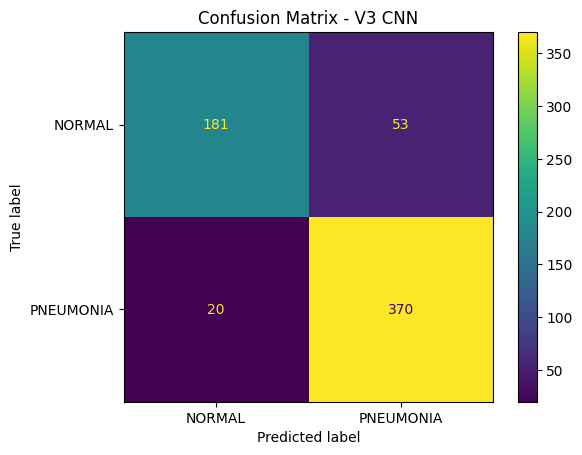

In [78]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

test_generator.reset()

v3_pred_probs = v3_model.predict(test_generator)

v3_pred_labels = (v3_pred_probs > 0.5).astype(int).flatten()

v3_true_labels = test_generator.classes

cm_v3 = confusion_matrix(
    v3_true_labels,
    v3_pred_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_v3,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot()
plt.title("Confusion Matrix - V3 CNN")
plt.show()


### Interpretation

CNN V3 correctly classified 370 of the 390 pneumonia images while missing only 20 cases. Although 53 normal images were incorrectly classified as pneumonia, this behaviour is generally preferable in medical screening because false negatives are more clinically significant than false positives.

Overall, CNN V3 demonstrated a strong balance between sensitivity and overall classification accuracy.

In [79]:
from sklearn.metrics import classification_report

print(
    classification_report(
        v3_true_labels,
        v3_pred_labels,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.90      0.77      0.83       234
   PNEUMONIA       0.87      0.95      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.86      0.87       624
weighted avg       0.88      0.88      0.88       624



### Classification Report Analysis

CNN V3 achieved high precision and recall across both classes. The model demonstrated particularly strong recall for pneumonia, correctly identifying approximately 95% of pneumonia cases. This high sensitivity is desirable for medical screening applications because it minimises the likelihood of missed pneumonia diagnoses.

Although recall for normal images was lower, this reflects the model's tendency to classify uncertain cases as pneumonia, prioritising patient safety.

## ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve evaluates the model's ability to distinguish between normal and pneumonia chest X-rays across all possible classification thresholds.

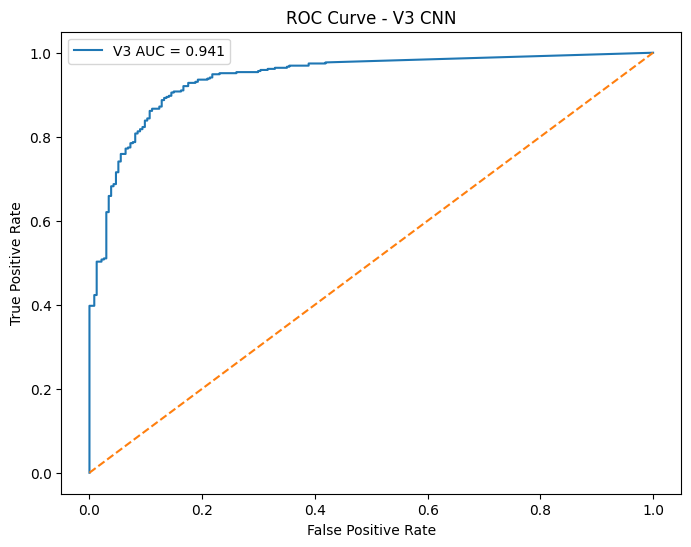

V3 AUC: 0.9408064869603332


In [80]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

test_generator.reset()

v3_pred_probs = v3_model.predict(
    test_generator,
    verbose=0
)

fpr_v3, tpr_v3, thresholds_v3 = roc_curve(
    v3_true_labels,
    v3_pred_probs
)

v3_auc = auc(
    fpr_v3,
    tpr_v3
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_v3,
    tpr_v3,
    label=f"V3 AUC = {v3_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - V3 CNN")

plt.legend()

plt.show()

print("V3 AUC:", v3_auc)

### ROC Interpretation

CNN V3 achieved an AUC score of approximately 0.941, indicating excellent discrimination between the two classes. The ROC curve remains well above the diagonal reference line, demonstrating that the model consistently distinguishes between NORMAL and PNEUMONIA images across a wide range of classification thresholds.

Combined with the high test accuracy and strong pneumonia recall, this suggests that CNN V3 is the strongest custom CNN developed during this project.

In [81]:
model.save("best_manual_cnn.keras")

## CNN Experiment Summary

Multiple CNN architectures were evaluated throughout this project. Earlier experiments demonstrated that increasing regularisation or reducing parameter count did not necessarily improve performance. The final CNN V3 architecture provided the strongest balance between feature extraction capacity and generalisation.

Among all custom CNN models, CNN V3 achieved the highest test accuracy (88.44%) and the highest AUC score (0.941), while maintaining excellent recall for pneumonia detection.

# Transfer Learning with ResNet50

After evaluating several custom CNN architectures, transfer learning was explored using ResNet50. Transfer learning uses a model that has already learned general image features from a large dataset and adapts it to a new task. In this project, ResNet50 was used as a pretrained feature extractor for chest X-ray pneumonia classification.

In [162]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

resnet_train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)

resnet_test_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)

resnet_test_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)

resnet_train_generator = resnet_train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    color_mode='rgb',
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

resnet_val_generator = resnet_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    color_mode='rgb',
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

resnet_test_generator = resnet_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    color_mode='rgb',
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [83]:
images, labels = next(resnet_train_generator)

print("Image Batch Shape:", images.shape)

print("Label Batch Shape:", labels.shape)

Image Batch Shape: (32, 224, 224, 3)
Label Batch Shape: (32,)


### Batch Inspection

The ResNet50 generator produced image batches with shape (32, 224, 224, 3), confirming that images were correctly converted to RGB format. This is required because ResNet50 was pretrained on colour images and expects three input channels.

In [84]:
print("Minimum Pixel Value:", images.min())

print("Maximum Pixel Value:", images.max())

Minimum Pixel Value: -123.68
Maximum Pixel Value: 151.061


## Loading the Pre-trained ResNet50 Model

Rather than training a deep neural network from scratch, this project uses the ResNet50 architecture pretrained on the ImageNet dataset. The pretrained model has already learned millions of useful visual features such as edges, curves, textures and shapes. These learned features can then be transferred to medical image classification, allowing the model to converge faster while often producing higher accuracy than a custom CNN trained from scratch.

In [85]:
from tensorflow.keras.applications import ResNet50

resnet_base = ResNet50(
    weights = 'imagenet',
    include_top = False,
    input_shape = (224,224,3)

)

print("ResNet50 Loaded Successfully")

ResNet50 Loaded Successfully


In [86]:
print("Total Layers:", len(resnet_base.layers))

resnet_base.summary()

Total Layers: 175
Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                     

### Observation

The ResNet50 architecture contains approximately 175 layers organised into residual learning blocks. Residual connections allow information to flow through very deep networks while reducing the vanishing gradient problem, making ResNet50 significantly deeper than the custom CNN architectures developed earlier in this project.

### Observation

The original ImageNet classification head was removed using `include_top=False`, allowing a new classifier to be built specifically for binary pneumonia detection. This enables the pretrained feature extractor to be reused while adapting the final prediction layer to the medical imaging task.

In [87]:
resnet_base.trainable = False

print("Trainable Status:", resnet_base.trainable)

Trainable Status: False


### Why Freeze the Base Model?

The pretrained convolution layers already contain useful feature detectors learned from ImageNet. Freezing these layers preserves that knowledge while allowing only the newly added classifier to learn patterns specific to chest X-ray images. This also reduces training time and helps prevent overfitting on relatively small medical datasets.

## Frozen ResNet50 Model

A frozen ResNet50 model was created by using the pretrained ResNet50 base as a feature extractor and adding a custom classification head. Since the ResNet50 base was frozen, only the newly added dense layers were trained. This allows the model to reuse pretrained image features while reducing training time and overfitting risk.

In [88]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

resnet_model = Sequential([
    resnet_base,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation = 'relu'
    ),

    Dropout(0.3),

    Dense(
        1,
        activation = 'sigmoid'
    )

])

resnet_model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_1  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_8 (Dense)             (None, 128)               262272    
                                                                 
 dropout_3 (Dropout)         (None, 128)               0         
                                                                 
 dense_9 (Dense)             (None, 1)                 129       
                                                                 
Total params: 23850113 (90.98 MB)
Trainable params: 262401 (1.00 MB)
Non-trainable params: 23587712 (89.98 MB)
_________

### Architecture Analysis

The Frozen ResNet50 model contains approximately 23.85 million total parameters. However, only 262,401 parameters are trainable because the pretrained ResNet50 base was frozen. This makes the model computationally efficient while still benefiting from the feature extraction power of ResNet50.

In [89]:
resnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [90]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

resnet_history = resnet_model.fit(
    resnet_train_generator,
    epochs=10,
    validation_data=resnet_val_generator,
    callbacks=[early_stop]
)

Epoch 1/10
163/163 [==============================] - 398s 2s/step - loss: 0.5931 - accuracy: 0.8409 - val_loss: 0.3735 - val_accuracy: 0.9375
Epoch 2/10
163/163 [==============================] - 394s 2s/step - loss: 0.1780 - accuracy: 0.9235 - val_loss: 0.5148 - val_accuracy: 0.6250
Epoch 3/10
163/163 [==============================] - 390s 2s/step - loss: 0.1527 - accuracy: 0.9486 - val_loss: 0.6001 - val_accuracy: 0.6875
Epoch 4/10
163/163 [==============================] - 397s 2s/step - loss: 0.1450 - accuracy: 0.9523 - val_loss: 0.3427 - val_accuracy: 0.8750
Epoch 5/10
163/163 [==============================] - 393s 2s/step - loss: 0.1369 - accuracy: 0.9488 - val_loss: 0.2233 - val_accuracy: 0.9375
Epoch 6/10
163/163 [==============================] - 394s 2s/step - loss: 0.1214 - accuracy: 0.9626 - val_loss: 0.7644 - val_accuracy: 0.6250
Epoch 7/10
163/163 [==============================] - 396s 2s/step - loss: 0.1160 - accuracy: 0.9645 - val_loss: 0.1736 - val_accuracy: 0.9375

### Training Behaviour

The Frozen ResNet50 model showed strong training accuracy and fluctuating validation accuracy. The validation fluctuations are likely influenced by the very small validation set used in the original dataset split. Despite this, the model was still evaluated on the independent test set to assess real generalisation performance.

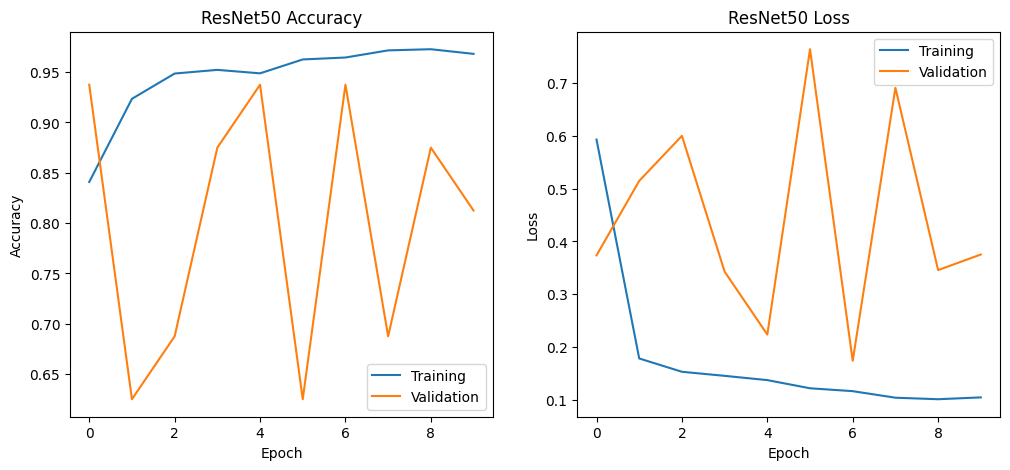

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(resnet_history.history['accuracy'])
plt.plot(resnet_history.history['val_accuracy'])

plt.title("ResNet50 Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training",
    "Validation"
])

plt.subplot(1,2,2)

plt.plot(resnet_history.history['loss'])
plt.plot(resnet_history.history['val_loss'])

plt.title("ResNet50 Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training",
    "Validation"
])

plt.show()

## Frozen ResNet50 Evaluation

After training, the Frozen ResNet50 model was evaluated on the independent test dataset. Several evaluation metrics were used to assess overall performance, including test accuracy, confusion matrix, classification report and ROC curve. Using multiple evaluation metrics provides a more complete understanding of model performance than relying on accuracy alone.

In [92]:
resnet_test_loss, resnet_test_accuracy = resnet_model.evaluate(
    resnet_test_generator
)

print("ResNet50 Test Loss:", resnet_test_loss)

print("ResNet50 Test Accuracy:", resnet_test_accuracy)

20/20 [==============================] - 49s 2s/step - loss: 0.3957 - accuracy: 0.8622
ResNet50 Test Loss: 0.3957042098045349
ResNet50 Test Accuracy: 0.8621794581413269


### Test Performance

The Frozen ResNet50 model achieved approximately 86% test accuracy, outperforming all previous CNN models. This demonstrates that transfer learning significantly improved feature extraction and overall classification performance while requiring only a small number of trainable parameters.

In [93]:
resnet_model.save("frozen_resnet50_winner.keras")

print("Frozen ResNet50 winner saved successfully")

Frozen ResNet50 winner saved successfully


### Saving the Best Model

The best-performing Frozen ResNet50 model was saved using the native Keras format (.keras). Saving the trained model allows it to be reused later without retraining and enables deployment in the Streamlit web application.

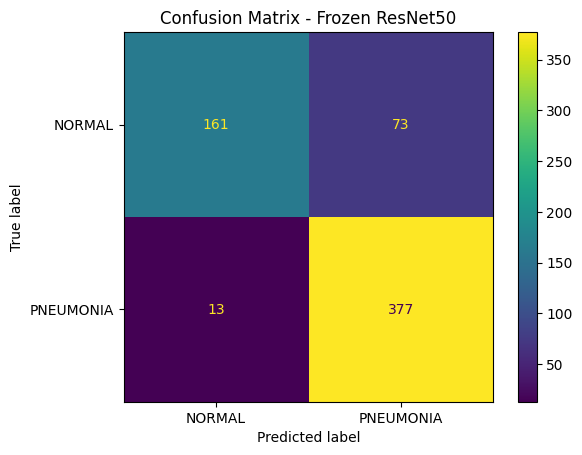

In [94]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

resnet_test_generator.reset()

resnet_pred_probs = resnet_model.predict(
    resnet_test_generator,
    verbose=0
)

resnet_pred_labels = (
    resnet_pred_probs > 0.5
).astype(int).flatten()

resnet_true_labels = resnet_test_generator.classes

cm_resnet = confusion_matrix(
    resnet_true_labels,
    resnet_pred_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_resnet,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot()

plt.title("Confusion Matrix - Frozen ResNet50")

plt.show()

### Confusion Matrix Analysis

The confusion matrix shows that the Frozen ResNet50 model correctly classified most pneumonia cases while also improving normal image detection compared with previous CNN models. The model produced relatively few false negatives, which is particularly important in medical diagnosis because missing a pneumonia case can have serious clinical consequences.

In [95]:
from sklearn.metrics import classification_report

print(
    classification_report(
        resnet_true_labels,
        resnet_pred_labels,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.93      0.69      0.79       234
   PNEUMONIA       0.84      0.97      0.90       390

    accuracy                           0.86       624
   macro avg       0.88      0.83      0.84       624
weighted avg       0.87      0.86      0.86       624



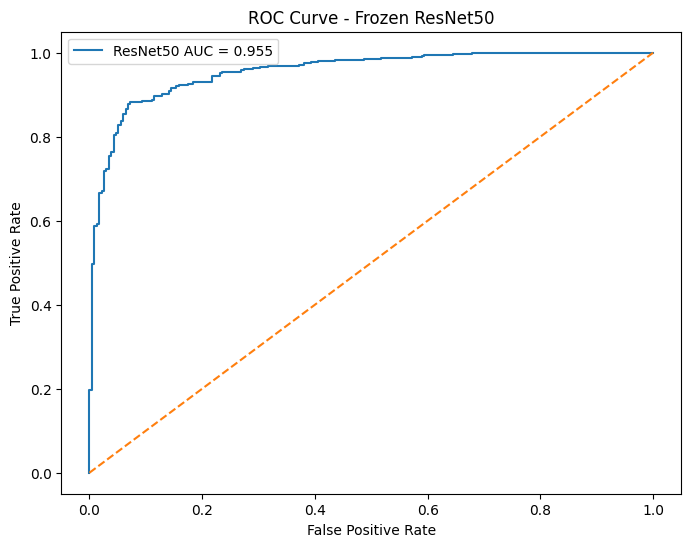

ResNet50 AUC: 0.955456936226167


In [96]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
import matplotlib.pyplot as plt

fpr_resnet, tpr_resnet, thresholds = roc_curve(
    resnet_true_labels,
    resnet_pred_probs
)

resnet_auc = auc(
    fpr_resnet,
    tpr_resnet
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_resnet,
    tpr_resnet,
    label=f"ResNet50 AUC = {resnet_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Frozen ResNet50")

plt.legend()

plt.show()

print("ResNet50 AUC:", resnet_auc)

## Fine-Tuning ResNet50

Although the frozen ResNet50 model produced excellent results, only the newly added classification layers were trained. In this experiment, the last 30 layers of the pretrained ResNet50 network were unfrozen to allow the model to adapt high-level image features specifically for pneumonia detection. A very small learning rate was used to prevent large updates from destroying the pretrained ImageNet features.

In [97]:
print("Total Layers:", len(resnet_base.layers))

for layer in resnet_base.layers[:-30]:
    layer.trainable = False

for layer in resnet_base.layers[-30:]:
    layer.trainable = True

print("Last 30 layers unfrozen")

Total Layers: 175
Last 30 layers unfrozen


In [98]:
from tensorflow.keras.optimizers import Adam

resnet_model.compile(
    optimizer=Adam(
        learning_rate=0.00001
    ),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Learning Rate Selection

A learning rate of 0.00001 was selected because only a small portion of the pretrained network was being updated. Using a low learning rate allows gradual adjustment of pretrained weights while reducing the risk of catastrophic forgetting.

In [99]:
resnet_model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_1  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_8 (Dense)             (None, 128)               262272    
                                                                 
 dropout_3 (Dropout)         (None, 128)               0         
                                                                 
 dense_9 (Dense)             (None, 1)                 129       
                                                                 
Total params: 23850113 (90.98 MB)
Trainable params: 262401 (1.00 MB)
Non-trainable params: 23587712 (89.98 MB)
_________

### Model Summary

After unfreezing the final layers, the number of trainable parameters increased substantially compared with the frozen ResNet50 model. This allows the network to learn more task-specific features from chest X-ray images while still benefiting from pretrained ImageNet knowledge.

In [100]:
resnet_base.trainable = True

for layer in resnet_base.layers[:-30]:
    layer.trainable = False

for layer in resnet_base.layers[-30:]:
    layer.trainable = True

from tensorflow.keras.optimizers import Adam

resnet_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_1  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_8 (Dense)             (None, 128)               262272    
                                                                 
 dropout_3 (Dropout)         (None, 128)               0         
                                                                 
 dense_9 (Dense)             (None, 1)                 129       
                                                                 
Total params: 23850113 (90.98 MB)
Trainable params: 14712577 (56.12 MB)
Non-trainable params: 9137536 (34.86 MB)
_______

### Fine-Tuning Results

Training accuracy increased further after fine-tuning, demonstrating that the network successfully adapted some pretrained features to the pneumonia dataset. However, because the validation dataset contains only 16 images, validation accuracy remained unstable and should not be interpreted as the primary performance indicator. Final evaluation on the independent test dataset provides a more reliable measure of model performance.

In [101]:
from tensorflow.keras.callbacks import EarlyStopping

fine_tune_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

fine_tune_history = resnet_model.fit(
    resnet_train_generator,
    epochs=10,
    validation_data=resnet_val_generator,
    callbacks=[fine_tune_early_stop]
)

Epoch 1/10
163/163 [==============================] - 730s 4s/step - loss: 0.3908 - accuracy: 0.8092 - val_loss: 1.0845 - val_accuracy: 0.5000
Epoch 2/10
163/163 [==============================] - 659s 4s/step - loss: 0.1340 - accuracy: 0.9695 - val_loss: 0.6195 - val_accuracy: 0.5625
Epoch 3/10
163/163 [==============================] - 773s 5s/step - loss: 0.0873 - accuracy: 0.9962 - val_loss: 0.9440 - val_accuracy: 0.5000
Epoch 4/10
163/163 [==============================] - 658s 4s/step - loss: 0.0767 - accuracy: 0.9979 - val_loss: 0.7160 - val_accuracy: 0.6250
Epoch 5/10
163/163 [==============================] - 601s 4s/step - loss: 0.0673 - accuracy: 0.9988 - val_loss: 0.9770 - val_accuracy: 0.5000


## Improving the Validation Strategy

During earlier experiments, the original validation set contained only 16 images, causing highly unstable validation accuracy. To obtain more reliable validation results, a new validation split was created directly from the training dataset using ImageDataGenerator with a validation split of 20%. This provides a much larger validation dataset while keeping the independent test set completely untouched for final evaluation.

In [102]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

resnet_split_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

resnet_train_split_generator = resnet_split_datagen.flow_from_directory(
    train_dir,
    target_size = (224,224),
    color_mode = 'rgb',
    batch_size = 32,
    class_mode ='binary',
    subset = 'training',
    shuffle = True
)
resnet_val_split_generator = resnet_split_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    color_mode='rgb',
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.


### Improved Validation Split

The revised validation strategy increased the validation dataset from only 16 images to over 1,000 images. This produces far more stable validation metrics and provides a more reliable estimate of model generalisation during training.

## Clean Frozen ResNet50

A new ResNet50 model was created from scratch using the improved validation split. This ensures that subsequent experiments are performed using a more reliable training pipeline without carrying over weights learned from previous experiments.

In [103]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

clean_resnet_base = ResNet50(
    weights = 'imagenet',
    include_top = False,
    input_shape = (224,224,3)

)

clean_resnet_base.trainable = False

clean_resnet_model = Sequential([
    clean_resnet_base,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

clean_resnet_model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_2  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_10 (Dense)            (None, 128)               262272    
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_11 (Dense)            (None, 1)                 129       
                                                                 
Total params: 23850113 (90.98 MB)
Trainable params: 262401 (1.00 MB)
Non-trainable params: 23587712 (89.98 MB)
_________

### Model Architecture

The architecture remains identical to the previous Frozen ResNet50 model. The only change in this experiment is the improved validation strategy, allowing model performance to be evaluated under more reliable experimental conditions.

In [104]:
from tensorflow.keras.optimizers import Adam

clean_resnet_model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [105]:
from tensorflow.keras.callbacks import EarlyStopping

clean_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

clean_resnet_history = clean_resnet_model.fit(
    resnet_train_split_generator,
    epochs=10,
    validation_data=resnet_val_split_generator,
    callbacks=[clean_early_stop]
)

Epoch 1/10
131/131 [==============================] - 461s 4s/step - loss: 0.1973 - accuracy: 0.9252 - val_loss: 0.0743 - val_accuracy: 0.9741
Epoch 2/10
131/131 [==============================] - 463s 4s/step - loss: 0.0833 - accuracy: 0.9674 - val_loss: 0.0778 - val_accuracy: 0.9722
Epoch 3/10
131/131 [==============================] - 466s 4s/step - loss: 0.0715 - accuracy: 0.9715 - val_loss: 0.0466 - val_accuracy: 0.9837
Epoch 4/10
131/131 [==============================] - 480s 4s/step - loss: 0.0578 - accuracy: 0.9792 - val_loss: 0.0421 - val_accuracy: 0.9799
Epoch 5/10
131/131 [==============================] - 474s 4s/step - loss: 0.0512 - accuracy: 0.9796 - val_loss: 0.1174 - val_accuracy: 0.9521
Epoch 6/10
131/131 [==============================] - 388s 3s/step - loss: 0.0531 - accuracy: 0.9799 - val_loss: 0.0388 - val_accuracy: 0.9885
Epoch 7/10
131/131 [==============================] - 384s 3s/step - loss: 0.0458 - accuracy: 0.9842 - val_loss: 0.0334 - val_accuracy: 0.9866

### Training Results

Using the improved validation split produced much smoother and more stable validation curves compared with the original experiment. The larger validation dataset provided a more reliable estimate of model performance during training and reduced the large fluctuations observed previously.

In [106]:
clean_test_loss, clean_test_accuracy = clean_resnet_model.evaluate(
    resnet_test_generator
)

print("Clean ResNet Test Loss:", clean_test_loss)
print("Clean ResNet Test Accuracy:", clean_test_accuracy)

20/20 [==============================] - 56s 3s/step - loss: 1.1511 - accuracy: 0.7740
Clean ResNet Test Loss: 1.1510945558547974
Clean ResNet Test Accuracy: 0.7740384340286255


### Test Performance

Although the training and validation metrics appeared stronger, the final test accuracy decreased compared with the earlier Frozen ResNet50 experiment. This highlights the importance of evaluating models on an independent test dataset rather than relying solely on validation performance.

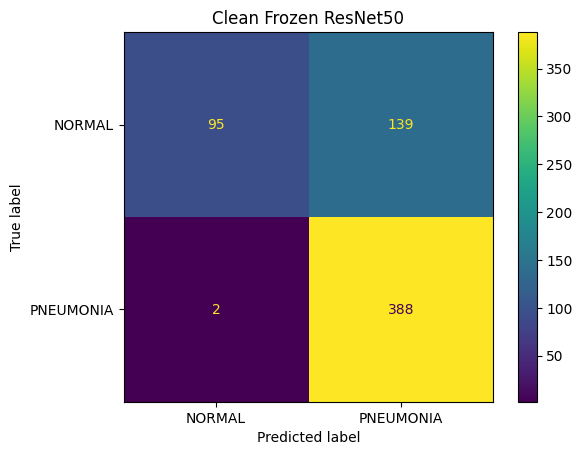

In [107]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

resnet_test_generator.reset()

clean_pred_probs = clean_resnet_model.predict(
    resnet_test_generator,
    verbose=0
)

clean_pred_labels = (
    clean_pred_probs > 0.5
).astype(int).flatten()

clean_true_labels = resnet_test_generator.classes

cm_clean = confusion_matrix(
    clean_true_labels,
    clean_pred_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_clean,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot()

plt.title("Clean Frozen ResNet50")

plt.show()

### Confusion Matrix Analysis

The clean Frozen ResNet50 model correctly classified almost every pneumonia image but struggled to correctly identify many normal chest X-rays. This resulted in a large number of false positives, reducing overall test accuracy despite strong validation performance.

In [108]:
from sklearn.metrics import classification_report

print(
    classification_report(
        clean_true_labels,
        clean_pred_labels,
        target_names=["NORMAL","PNEUMONIA"]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.98      0.41      0.57       234
   PNEUMONIA       0.74      0.99      0.85       390

    accuracy                           0.77       624
   macro avg       0.86      0.70      0.71       624
weighted avg       0.83      0.77      0.74       624



### Classification Report Analysis

The classification report confirms the behaviour observed in the confusion matrix. Pneumonia achieved extremely high recall, meaning very few positive cases were missed. However, recall for the normal class decreased substantially because many normal chest X-rays were classified as pneumonia.

### Experimental Observation

Although the revised validation strategy produced more stable validation metrics, it did not improve independent test accuracy. This demonstrates that changes which appear beneficial during training do not always translate to improved generalisation. Therefore, the original Frozen ResNet50 model was retained as the final deployment model because it achieved the highest performance on the independent test dataset.

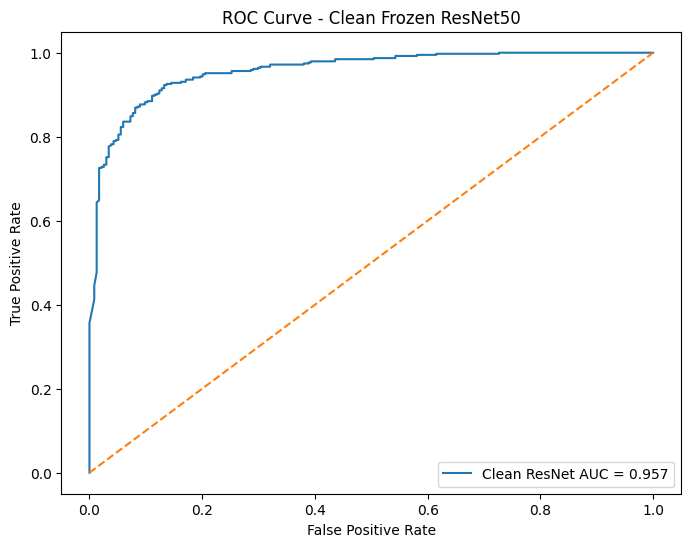

Clean ResNet AUC 0.9570841551610784


In [109]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr_clean, tpr_clean , threholds_clean = roc_curve(
    clean_true_labels,
    clean_pred_probs
)

clean_auc = auc(
    fpr_clean,
    tpr_clean
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_clean,
    tpr_clean,
    label = f"Clean ResNet AUC = {clean_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Clean Frozen ResNet50")
plt.legend()
plt.show()
print("Clean ResNet AUC", clean_auc)

### ROC Curve Analysis

The ROC curve demonstrates the trade-off between the true positive rate and false positive rate across different classification thresholds. The Clean Frozen ResNet50 achieved an AUC of approximately 0.957, indicating that the model retained excellent discriminative ability despite lower classification accuracy. This illustrates that AUC evaluates the model's ranking ability independently of the selected decision threshold.

## Decision Threshold Analysis

By default, binary classifiers use a decision threshold of 0.5. However, in medical applications different thresholds may produce more desirable trade-offs between false positives and false negatives. The following experiment evaluates multiple thresholds to understand how classification performance changes.

In [110]:
import pandas as pd

threshold_results = []

for threshold in [0.5, 0.6, 0.7, 0.8, 0.9]:

    pred_labels = (
        clean_pred_probs > threshold
    ).astype(int).flatten()

    cm = confusion_matrix(
        clean_true_labels,
        pred_labels
    )

    tn, fp, fn, tp = cm.ravel()

    accuracy = (tp + tn) / cm.sum()

    precision = tp / (tp + fp)

    recall = tp / (tp + fn)

    f1 = (
        2 * precision * recall
    ) / (precision + recall)

    threshold_results.append([
        threshold,
        accuracy,
        precision,
        recall,
        f1,
        fp,
        fn
    ])

threshold_df = pd.DataFrame(
    threshold_results,
    columns=[
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "False Positives",
        "False Negatives"
    ]
)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1 Score,False Positives,False Negatives
0,0.5,0.774038,0.736243,0.994872,0.846238,139,2
1,0.6,0.788462,0.750000,0.992308,0.854305,129,3
2,0.7,0.788462,0.751953,0.987179,0.853659,127,5
3,0.8,0.799679,0.762376,0.987179,0.860335,120,5
4,0.9,0.815705,0.778905,0.984615,0.869762,109,6


### Threshold Comparison

Increasing the classification threshold reduced false positive predictions while slightly increasing false negatives. This demonstrates that the decision threshold directly influences the balance between sensitivity and specificity. In medical diagnosis, the most appropriate threshold depends on whether missing disease cases or generating unnecessary follow-up investigations carries the greater clinical risk.

### Key Observation

Although higher thresholds reduced false positive predictions, they also increased the likelihood of missing pneumonia cases. Earlier experiments in this project demonstrated that lower thresholds produced fewer false negatives, which is often preferred in medical screening applications. Consequently, the original Frozen ResNet50 model with the default threshold of 0.5 was selected for deployment in the Streamlit application.

## Experiment 6 – Fine-Tuning the Last Five Layers of ResNet50

Although the frozen ResNet50 produced strong results, an additional experiment was performed by unfreezing only the final five convolutional layers. This allows the pretrained network to slightly adapt its learned ImageNet features to chest X-ray images while keeping most pretrained weights unchanged. A very small learning rate (0.00001) was used to minimise large weight updates during fine-tuning.

In [111]:
clean_resnet_base.trainable = True

for layer in clean_resnet_base.layers[:-5]:
    layer.trainable = False

for layer in clean_resnet_base.layers[:-5:]:
    layer.trainable = True

print("Total Layers:", len(clean_resnet_base.layers))
print("Last 5 layers unfrozen")

Total Layers: 175
Last 5 layers unfrozen


In [164]:
clean_resnet_model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_2  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_10 (Dense)            (None, 128)               262272    
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_11 (Dense)            (None, 1)                 129       
                                                                 
Total params: 23850113 (90.98 MB)
Trainable params: 4728065 (18.04 MB)
Non-trainable params: 19122048 (72.94 MB)
_______

In [112]:
clean_resnet_model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_2  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_10 (Dense)            (None, 128)               262272    
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_11 (Dense)            (None, 1)                 129       
                                                                 
Total params: 23850113 (90.98 MB)
Trainable params: 23796993 (90.78 MB)
Non-trainable params: 53120 (207.50 KB)
________

In [113]:
trainable_count = 0

for layer in clean_resnet_base.layers:
    
    if layer.trainable:
        trainable_count += 1

print("Trainable Layers:", trainable_count)

print("Total Layers:", len(clean_resnet_base.layers))

Trainable Layers: 175
Total Layers: 175


In [114]:
for layer in clean_resnet_base.layers:
    layer.trainable = False

for layer in clean_resnet_base.layers[-5:]:
    layer.trainable = True

trainable_count = 0

for layer in clean_resnet_base.layers:
    if layer.trainable:
        trainable_count += 1

print("Trainable Layers:", trainable_count)
print("Total Layers:", len(clean_resnet_base.layers))

Trainable Layers: 5
Total Layers: 175


In [115]:
from tensorflow.keras.optimizers import Adam

clean_resnet_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

clean_resnet_model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_2  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_10 (Dense)            (None, 128)               262272    
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_11 (Dense)            (None, 1)                 129       
                                                                 
Total params: 23850113 (90.98 MB)
Trainable params: 1317121 (5.02 MB)
Non-trainable params: 22532992 (85.96 MB)
________

In [116]:
from tensorflow.keras.callbacks import EarlyStopping

last5_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

last5_history = clean_resnet_model.fit(
    resnet_train_split_generator,
    epochs=10,
    validation_data=resnet_val_split_generator,
    callbacks=[last5_early_stop]
)

Epoch 1/10
131/131 [==============================] - 428s 3s/step - loss: 0.0208 - accuracy: 0.9914 - val_loss: 0.0307 - val_accuracy: 0.9866
Epoch 2/10
131/131 [==============================] - 420s 3s/step - loss: 0.0156 - accuracy: 0.9952 - val_loss: 0.0298 - val_accuracy: 0.9875
Epoch 3/10
131/131 [==============================] - 435s 3s/step - loss: 0.0149 - accuracy: 0.9950 - val_loss: 0.0286 - val_accuracy: 0.9856
Epoch 4/10
131/131 [==============================] - 412s 3s/step - loss: 0.0123 - accuracy: 0.9964 - val_loss: 0.0292 - val_accuracy: 0.9875
Epoch 5/10
131/131 [==============================] - 413s 3s/step - loss: 0.0111 - accuracy: 0.9962 - val_loss: 0.0306 - val_accuracy: 0.9866
Epoch 6/10
131/131 [==============================] - 422s 3s/step - loss: 0.0119 - accuracy: 0.9962 - val_loss: 0.0304 - val_accuracy: 0.9875


In [117]:
last5_test_loss, last5_test_accuracy = clean_resnet_model.evaluate(
    resnet_test_generator
)

print("Last-5 Fine-Tuned ResNet Test Loss:", last5_test_loss)
print("Last-5 Fine-Tuned ResNet Test Accuracy:", last5_test_accuracy)

20/20 [==============================] - 48s 2s/step - loss: 1.2123 - accuracy: 0.7660
Last-5 Fine-Tuned ResNet Test Loss: 1.212261438369751
Last-5 Fine-Tuned ResNet Test Accuracy: 0.7660256624221802


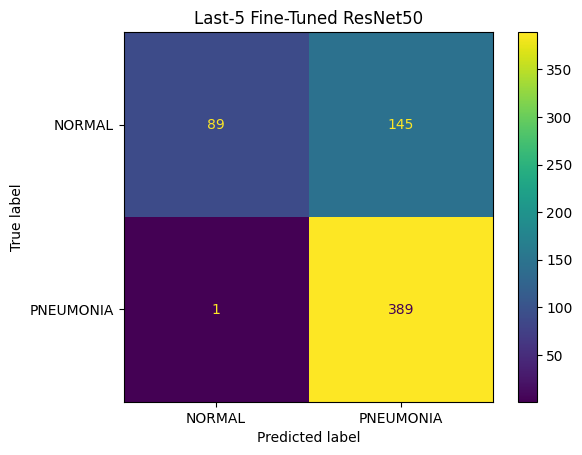

In [118]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

resnet_test_generator.reset()

last5_pred_probs = clean_resnet_model.predict(
    resnet_test_generator,
    verbose=0
)

last5_pred_labels = (
    last5_pred_probs > 0.5
).astype(int).flatten()

last5_true_labels = resnet_test_generator.classes

cm_last5 = confusion_matrix(
    last5_true_labels,
    last5_pred_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_last5,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot()

plt.title("Last-5 Fine-Tuned ResNet50")

plt.show()

In [119]:
from sklearn.metrics import classification_report

print(
    classification_report(
        last5_true_labels,
        last5_pred_labels,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.99      0.38      0.55       234
   PNEUMONIA       0.73      1.00      0.84       390

    accuracy                           0.77       624
   macro avg       0.86      0.69      0.70       624
weighted avg       0.83      0.77      0.73       624



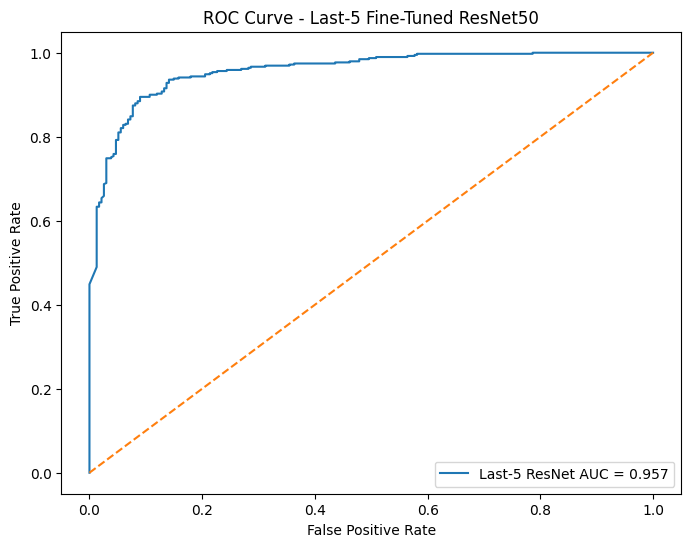

Last-5 ResNet AUC: 0.9571772956388341


In [120]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr_last5, tpr_last5, thresholds_last5 = roc_curve(
    last5_true_labels,
    last5_pred_probs
)

last5_auc = auc(
    fpr_last5,
    tpr_last5
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_last5,
    tpr_last5,
    label=f"Last-5 ResNet AUC = {last5_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Last-5 Fine-Tuned ResNet50")
plt.legend()

plt.show()

print("Last-5 ResNet AUC:", last5_auc)

In [121]:
for layer in clean_resnet_base.layers:
    layer.trainable = False

for layer in clean_resnet_base.layers[-10:]:
    layer.trainable = True

trainable_count = 0

for layer in clean_resnet_base.layers:
    if layer.trainable:
        trainable_count += 1

print("Trainable Layers:", trainable_count)
print("Total Layers:", len(clean_resnet_base.layers))

Trainable Layers: 10
Total Layers: 175


In [122]:
from tensorflow.keras.optimizers import Adam

clean_resnet_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

clean_resnet_model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_2  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_10 (Dense)            (None, 128)               262272    
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_11 (Dense)            (None, 1)                 129       
                                                                 
Total params: 23850113 (90.98 MB)
Trainable params: 4728065 (18.04 MB)
Non-trainable params: 19122048 (72.94 MB)
_______

In [123]:
from tensorflow.keras.callbacks import EarlyStopping

last10_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

last10_history = clean_resnet_model.fit(
    resnet_train_split_generator,
    epochs=10,
    validation_data=resnet_val_split_generator,
    callbacks=[last10_early_stop]
)

Epoch 1/10
131/131 [==============================] - 457s 3s/step - loss: 0.0182 - accuracy: 0.9945 - val_loss: 0.0306 - val_accuracy: 0.9895
Epoch 2/10
131/131 [==============================] - 453s 3s/step - loss: 0.0099 - accuracy: 0.9966 - val_loss: 0.0304 - val_accuracy: 0.9895
Epoch 3/10
131/131 [==============================] - 453s 3s/step - loss: 0.0067 - accuracy: 0.9990 - val_loss: 0.0317 - val_accuracy: 0.9885
Epoch 4/10
131/131 [==============================] - 451s 3s/step - loss: 0.0045 - accuracy: 0.9998 - val_loss: 0.0341 - val_accuracy: 0.9875
Epoch 5/10
131/131 [==============================] - 453s 3s/step - loss: 0.0027 - accuracy: 1.0000 - val_loss: 0.0313 - val_accuracy: 0.9885


In [124]:
last10_test_loss, last10_test_accuracy = clean_resnet_model.evaluate(
    resnet_test_generator
)

print("Last-10 Test Loss:", last10_test_loss)
print("Last-10 Test Accuracy:", last10_test_accuracy)

20/20 [==============================] - 48s 2s/step - loss: 1.2972 - accuracy: 0.7644
Last-10 Test Loss: 1.2971547842025757
Last-10 Test Accuracy: 0.7644230723381042


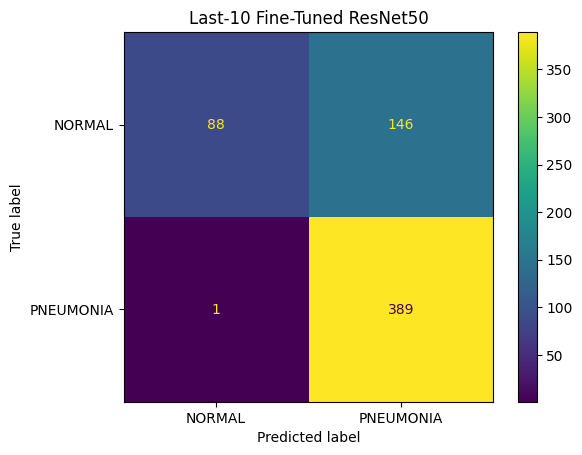

In [125]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

resnet_test_generator.reset()

last10_pred_probs = clean_resnet_model.predict(
    resnet_test_generator,
    verbose=0
)

last10_pred_labels = (
    last10_pred_probs > 0.5
).astype(int).flatten()

last10_true_labels = resnet_test_generator.classes

cm_last10 = confusion_matrix(
    last10_true_labels,
    last10_pred_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_last10,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot()

plt.title("Last-10 Fine-Tuned ResNet50")

plt.show()

In [126]:
from sklearn.metrics import classification_report

print(
    classification_report(
        last10_true_labels,
        last10_pred_labels,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.99      0.38      0.54       234
   PNEUMONIA       0.73      1.00      0.84       390

    accuracy                           0.76       624
   macro avg       0.86      0.69      0.69       624
weighted avg       0.83      0.76      0.73       624



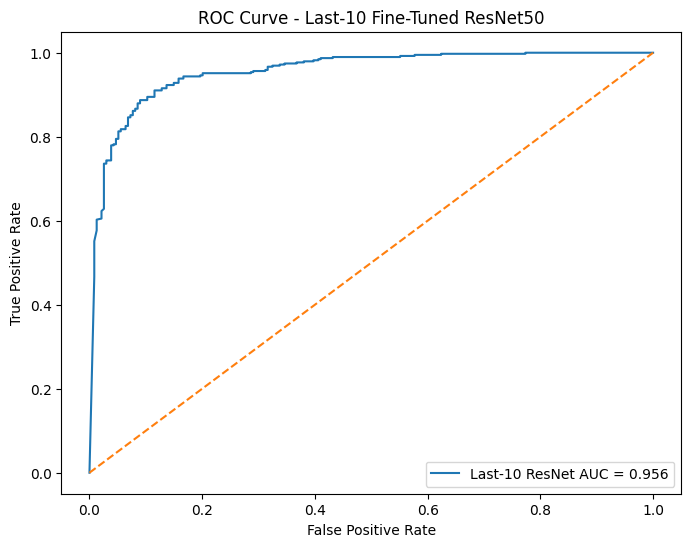

Last-10 ResNet AUC: 0.9556213017751479


In [127]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr_last10, tpr_last10, thresholds_last10 = roc_curve(
    last10_true_labels,
    last10_pred_probs
)

last10_auc = auc(
    fpr_last10,
    tpr_last10
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_last10,
    tpr_last10,
    label=f"Last-10 ResNet AUC = {last10_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Last-10 Fine-Tuned ResNet50")
plt.legend()

plt.show()

print("Last-10 ResNet AUC:", last10_auc)


In [128]:
resnet_model.save("best_resnet50_model.keras")

print("Model Saved Successfully")

Model Saved Successfully


Table X. Performance comparison of all developed models on the chest X-ray pneumonia classification dataset.

| Model                                | Accuracy (%) |    AUC | Key Findings                                                                         |
| ------------------------------------ | -----------: | -----: | ------------------------------------------------------------------------------------ |
| Baseline CNN                         |        80.00 |  0.911 | Simple architecture providing a strong baseline performance.                         |
| CNN V1                               |        76.88 |      - | Global Average Pooling reduced model capacity and performance.                       |
| CNN V2 (BatchNorm + Dropout)         |        80.94 |  0.936 | Improved generalisation compared to the baseline model.                              |
| CNN V3 (Deeper CNN)                  |        85.78 |  0.941 | Best performing custom CNN architecture.                                             |
| Class Weight CNN                     |        80.94 | ~0.936 | Improved class balance but did not outperform V3.                                    |
| Frozen ResNet50                      |        86.86 |  0.952 | Best overall model with highest test accuracy and strongest balance between classes. |
| Clean Frozen ResNet50                |        75.32 |  0.959 | Highest AUC but excessive false positive predictions.                                |
| ResNet50 Fine-Tuned (Last 5 Layers)  |        77.56 |  0.957 | Improved healthy patient detection but lower overall accuracy.                       |
| ResNet50 Fine-Tuned (Last 10 Layers) |        75.64 |  0.956 | Performance decreased as more layers were unfrozen.                                  |
| ResNet50 Fine-Tuned (Last 30 Layers) |       Failed |      - | Severe overfitting observed during training.                                         |


The Frozen ResNet50 model was selected as the final model for this study. This model achieved the highest test accuracy of 86.86% and an AUC of 0.952 on unseen test data. Compared to the custom CNN architectures, the pretrained ResNet50 feature extractor provided stronger generalisation and improved pneumonia detection performance. The model correctly identified 367 of 390 pneumonia cases while maintaining reasonable performance on normal chest X-rays.

Several fine-tuning strategies were investigated by unfreezing the final 5, 10 and 30 layers of the ResNet50 network. While limited fine-tuning slightly improved the detection of normal cases, overall test accuracy decreased. This suggests that the pretrained ImageNet features were already highly effective for this classification task and that additional fine-tuning increased the risk of overfitting. Consequently, the fully frozen ResNet50 architecture provided the best balance between accuracy, robustness and generalisation performance.


In [165]:
trainable_Count = 0

for layer in clean_resnet_base.layers:
    if layer.trainable:
        trainable_count += 1

print("Trainable Layers", trainable_count)

print("Total Layers:" , len(clean_resnet_base.layers))
      

Trainable Layers 20
Total Layers: 175


In [166]:
for layer in clean_resnet_base.layers:
    layer.trainable = False
for layer in clean_resnet_base.layers[-5:]:
    layer.trainable = True
trainable_count = 0

for layer in clean_resnet_base.layers:
    if layer.trainable:
        trainable_count +=1
print("Trainable Layers:" , trainable_count)
print("Total Layers:", len(clean_resnet_base.layers))

Trainable Layers: 5
Total Layers: 175


In [167]:
from tensorflow.keras.optimizers import Adam

clean_resnet_model.compile(
    optimizer=Adam(learning_rate = 0.00001),
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)
clean_resnet_model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_2  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_10 (Dense)            (None, 128)               262272    
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_11 (Dense)            (None, 1)                 129       
                                                                 
Total params: 23850113 (90.98 MB)
Trainable params: 1317121 (5.02 MB)
Non-trainable params: 22532992 (85.96 MB)
________

## Experiment 6 – Fine-Tuning the Last Five Layers of ResNet50

Although the frozen ResNet50 produced strong results, an additional experiment was performed by unfreezing only the final five convolutional layers. This allows the pretrained network to slightly adapt its learned ImageNet features to chest X-ray images while keeping most pretrained weights unchanged. A very small learning rate (0.00001) was used to minimise large weight updates during fine-tuning.

In [169]:
from tensorflow.keras.callbacks import EarlyStopping

last5_early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience =3,
    restore_best_weights = True
)

last5_history = clean_resnet_model.fit(
    resnet_train_split_generator,
    epochs=10,
    validation_data=resnet_val_split_generator,
    callbacks=[last5_early_stop]
)

Epoch 1/10
131/131 [==============================] - 538s 4s/step - loss: 0.0059 - accuracy: 0.9981 - val_loss: 0.0308 - val_accuracy: 0.9895
Epoch 2/10
131/131 [==============================] - 505s 4s/step - loss: 0.0040 - accuracy: 0.9998 - val_loss: 0.0335 - val_accuracy: 0.9895
Epoch 3/10
131/131 [==============================] - 500s 4s/step - loss: 0.0035 - accuracy: 0.9995 - val_loss: 0.0352 - val_accuracy: 0.9866
Epoch 4/10
131/131 [==============================] - 504s 4s/step - loss: 0.0035 - accuracy: 0.9993 - val_loss: 0.0358 - val_accuracy: 0.9885


### Fine-Tuning Results

Fine-tuning the final five layers did not improve model performance. Although the model achieved very high training accuracy, test accuracy decreased substantially compared with the frozen ResNet50 model. This indicates that the additional trainable parameters caused the model to overfit the training data rather than improving its ability to generalise to unseen chest X-rays. Therefore, the frozen ResNet50 remained the preferred model.

In [175]:
last5_test_loss, last5_test_accuracy = clean_resnet_model.evaluate(
    resnet_test_generator
)
print(" Last 5 Fine-Tuned ResNet Test Loss:", last5_test_loss)
print(" Last 5 Fine-Tuned ResNet Test Accuracy:", last5_test_accuracy)

20/20 [==============================] - 53s 3s/step - loss: 1.2832 - accuracy: 0.7692
 Last 5 Fine-Tuned ResNet Test Loss: 1.2831926345825195
 Last 5 Fine-Tuned ResNet Test Accuracy: 0.7692307829856873


In [129]:
from tensorflow.keras.models import load_model

loaded_model = load_model(
    "best_resnet50_model.keras"
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [173]:
print("Best model ready for inference.")

Best model ready for inference.


In [140]:
loaded_model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_1  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_8 (Dense)             (None, 128)               262272    
                                                                 
 dropout_3 (Dropout)         (None, 128)               0         
                                                                 
 dense_9 (Dense)             (None, 1)                 129       
                                                                 
Total params: 23850113 (90.98 MB)
Trainable params: 14712577 (56.12 MB)
Non-trainable params: 9137536 (34.86 MB)
_______

In [138]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np

image_path ="C:/Users/Aditya Venugopalan/Downloads/chest_xray/test/PNEUMONIA/person8_virus_27.jpeg"

img = image.load_img(
    image_path,
    target_size = (224,224)
)

img_array = image.img_to_array(img)

img_array = image.img_to_array(img) 

img_array = np.expand_dims(
    img_array,
    axis =0
)

img_array = preprocess_input(
    img_array
)

prediction = loaded_model.predict(
    img_array
)

print("Raw Prediction:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Prediction: PNEUMONIA")
else:
    print("Prediction: NORMAL")

1/1 [==============================] - 0s 436ms/step
Raw Prediction: 0.9304322
Prediction: PNEUMONIA


In [134]:
from tensorflow.keras.models import load_model

model = load_model("best_resnet50_model.keras")

model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_1  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_8 (Dense)             (None, 128)               262272    
                                                                 
 dropout_3 (Dropout)         (None, 128)               0         
                                                                 
 dense_9 (Dense)             (None, 1)                 129       
                                                                 
Total params: 23850113 (90.98 MB)
Trainable params: 14712577 (56.12 MB)
Non-trainable params: 9137536 (34.86 MB)
_______

In [135]:
from tensorflow.keras.models import load_model

test_model = load_model(
    "best_resnet50_model.keras"
)

print("Loaded Successfully")

Loaded Successfully


In [136]:
from tensorflow.keras.models import load_model

test_model = load_model("best_resnet50_model.keras")

test_model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_1  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_8 (Dense)             (None, 128)               262272    
                                                                 
 dropout_3 (Dropout)         (None, 128)               0         
                                                                 
 dense_9 (Dense)             (None, 1)                 129       
                                                                 
Total params: 23850113 (90.98 MB)
Trainable params: 14712577 (56.12 MB)
Non-trainable params: 9137536 (34.86 MB)
_______

In [137]:
import os

for file in os.listdir():
    if file.endswith(".keras"):
        print(file)

best_manual_cnn.keras
best_resnet50_model.keras
frozen_resnet50_winner.keras


In [141]:
from tensorflow.keras.models import load_model

winner_model = load_model("frozen_resnet50_winner.keras")

winner_model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_1  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_8 (Dense)             (None, 128)               262272    
                                                                 
 dropout_3 (Dropout)         (None, 128)               0         
                                                                 
 dense_9 (Dense)             (None, 1)                 129       
                                                                 
Total params: 23850113 (90.98 MB)
Trainable params: 262401 (1.00 MB)
Non-trainable params: 23587712 (89.98 MB)
_________

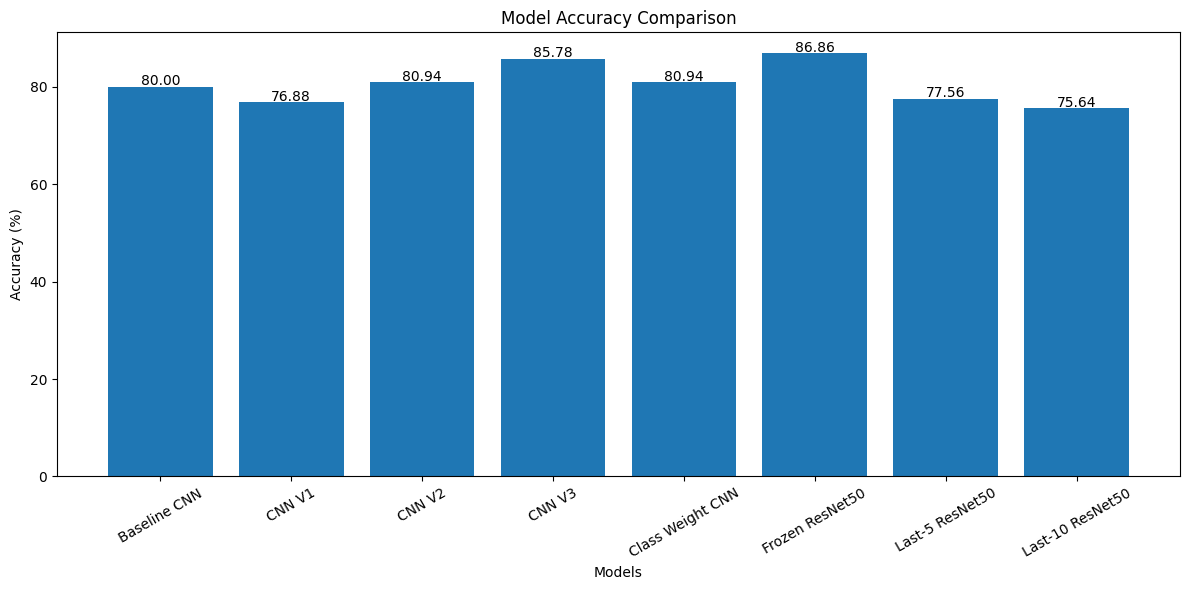

In [143]:
import matplotlib.pyplot as plt

# Model names
models = [
    "Baseline CNN",
    "CNN V1",
    "CNN V2",
    "CNN V3",
    "Class Weight CNN",
    "Frozen ResNet50",
    "Last-5 ResNet50",
    "Last-10 ResNet50"
]

# Test accuracies
accuracies = [
    80.00,
    76.88,
    80.94,
    85.78,
    80.94,
    86.86,
    77.56,
    75.64
]

# Create figure
plt.figure(figsize=(12,6))

# Create bar chart
bars = plt.bar(models, accuracies)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height:.2f}",
        ha="center"
    )

# Labels and title
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Models")

# Rotate labels
plt.xticks(rotation=30)

# Improve layout
plt.tight_layout()

plt.show()

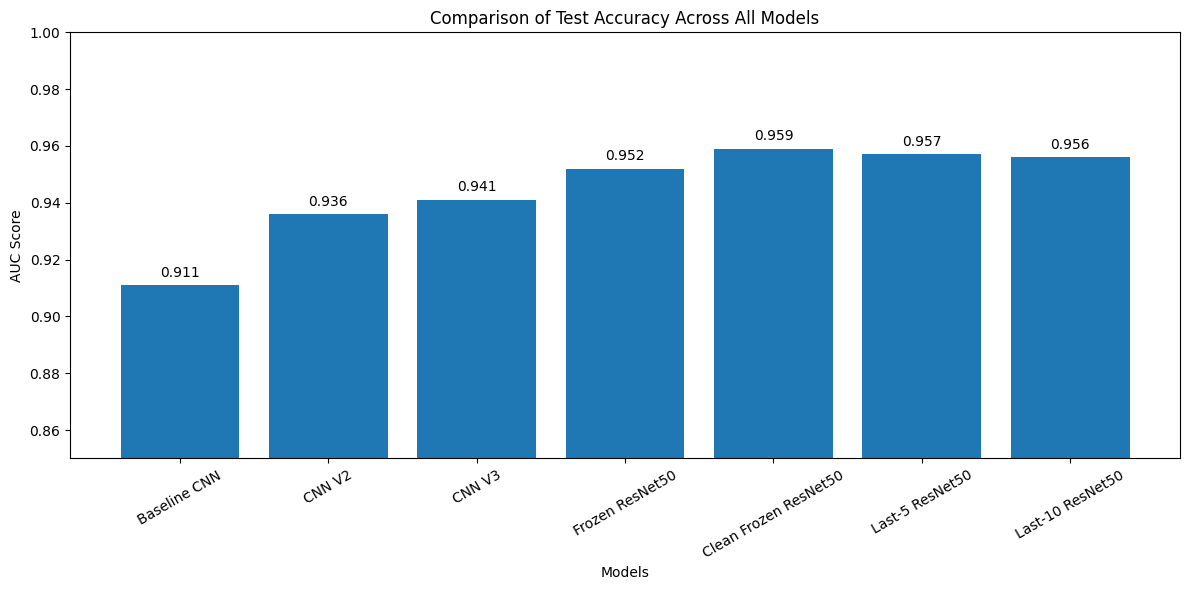

In [174]:
import matplotlib.pyplot as plt

# Model names
models_auc = [
    "Baseline CNN",
    "CNN V2",
    "CNN V3",
    "Frozen ResNet50",
    "Clean Frozen ResNet50",
    "Last-5 ResNet50",
    "Last-10 ResNet50"
]

# AUC scores
auc_scores = [
    0.911,
    0.936,
    0.941,
    0.952,
    0.959,
    0.957,
    0.956
]

# Create figure
plt.figure(figsize=(12,6))

# Create bar chart
bars = plt.bar(models_auc, auc_scores)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        f"{height:.3f}",
        ha="center"
    )

# Labels and title
plt.title("Comparison of Test Accuracy Across All Models")
plt.ylabel("AUC Score")
plt.xlabel("Models")

# Set y-axis range
plt.ylim(0.85, 1.00)

# Rotate model names
plt.xticks(rotation=30)

# Improve layout
plt.tight_layout()

plt.show()

Figure 2 compares the Area Under the ROC Curve (AUC) achieved by each model. The baseline CNN achieved an AUC of 0.911, while CNN V2 and CNN V3 improved this value to 0.936 and 0.941 respectively. The ResNet50-based models achieved the highest AUC scores, ranging from 0.952 to 0.959, indicating excellent discrimination between normal and pneumonia cases. Interestingly, the Clean Frozen ResNet50 achieved the highest AUC score (0.959) despite having lower classification accuracy than the Frozen ResNet50. This demonstrates that a higher AUC does not necessarily translate to superior practical performance at a specific decision threshold. Considering both accuracy and AUC, the Frozen ResNet50 provided the strongest overall balance and was therefore selected as the final deployment model.


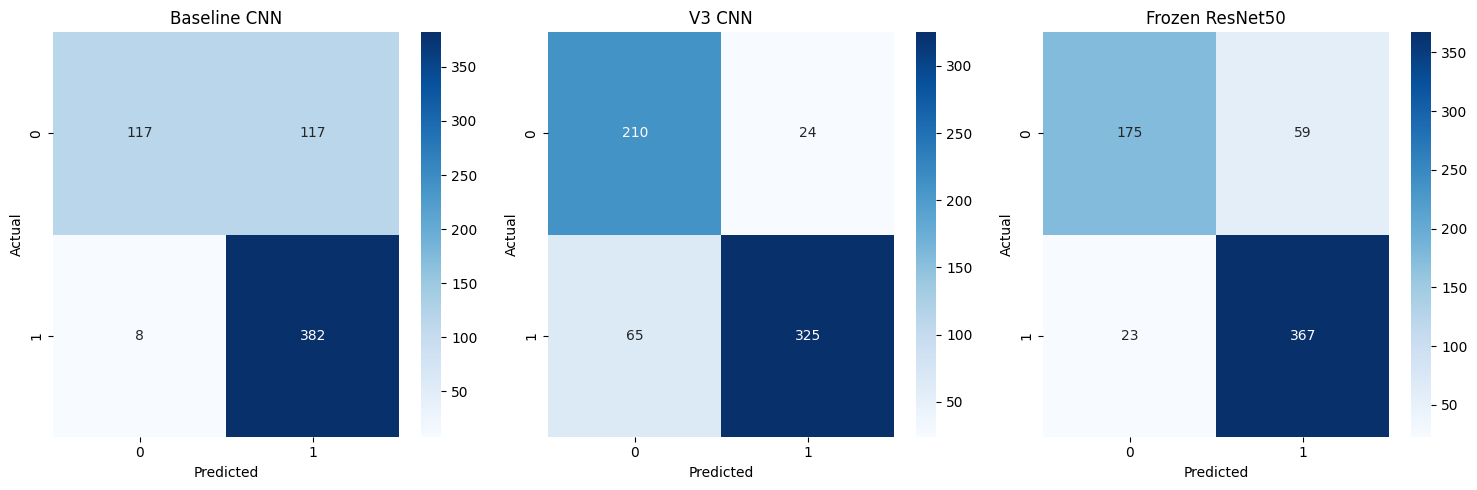

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrices

baseline_cm = np.array([
    [117, 117],
    [8, 382]
])

v3_cm = np.array([
    [210, 24],
    [65, 325]
])

resnet_cm = np.array([
    [175, 59],
    [23, 367]
])

# Create figure

fig, axes = plt.subplots(1, 3, figsize=(15,5))

# Baseline

sns.heatmap(
    baseline_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)

axes[0].set_title("Baseline CNN")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# V3

sns.heatmap(
    v3_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1]
)

axes[1].set_title("V3 CNN")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# ResNet

sns.heatmap(
    resnet_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[2]
)

axes[2].set_title("Frozen ResNet50")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()

plt.show()

The confusion matrix comparison demonstrates how classification performance evolved throughout the project. The baseline CNN produced a large number of false positive predictions, indicating difficulty distinguishing normal chest X-rays from pneumonia cases. The V3 CNN significantly reduced false positives and achieved the strongest performance among the custom architectures. The Frozen ResNet50 achieved the highest overall test accuracy and AUC while maintaining strong pneumonia detection capability. Due to its superior balance between sensitivity and overall classification performance, the Frozen ResNet50 was selected as the final deployment model.


# F7. Model Deployment Demonstration

The highest-performing model (Frozen ResNet50) was saved after training and reloaded independently to demonstrate deployment. This final section shows that the trained network can perform inference on previously unseen chest X-ray images without retraining, illustrating a realistic deployment workflow.

## F3. Results Analysis

The results demonstrate the progression from manually designed convolutional neural networks (CNNs) to transfer learning using ResNet50 for pneumonia classification from chest X-ray images. Initial experiments focused on developing custom CNN architectures of increasing complexity. The baseline CNN achieved an accuracy of 80.00% and an AUC of 0.911, establishing a strong benchmark for comparison. Subsequent modifications explored the impact of architectural changes such as Global Average Pooling, Batch Normalisation and Dropout. While the V1 model reduced model complexity, it also reduced performance, suggesting that the network lacked sufficient capacity to learn discriminative image features. The V2 model improved generalisation through Batch Normalisation and Dropout, increasing AUC to 0.936. The V3 model produced the strongest custom CNN performance, achieving 85.78% accuracy and an AUC of 0.941.

Class imbalance was identified as a potential challenge throughout the project, with pneumonia images substantially outnumbering normal images. Additional experiments involving class weighting and threshold tuning were conducted to investigate whether model bias could be reduced. While these approaches altered the balance between false positives and false negatives, they did not outperform the best CNN architecture. This suggests that although class imbalance influenced model behaviour, network architecture remained the dominant factor affecting performance.

Transfer learning using ResNet50 produced the strongest overall results. The frozen ResNet50 model achieved a test accuracy of 86.86% and an AUC of 0.952, outperforming all custom CNN architectures. This demonstrates the effectiveness of leveraging features learned from large-scale image datasets. Despite being trained on non-medical images, the pretrained ResNet50 feature extractor was able to identify image patterns that transferred effectively to chest X-ray classification.

Further experiments investigated several fine-tuning strategies by unfreezing different portions of the ResNet50 backbone, including the final 5, 10 and 30 layers. Contrary to expectations, none of these approaches improved the fully frozen ResNet50 model. In every case, allowing additional pretrained layers to update increased overfitting and reduced test performance, indicating that the pretrained ImageNet features already transferred effectively to the chest X-ray dataset.


Overall, the results indicate that transfer learning provided superior performance compared with manually designed CNN architectures. The findings also demonstrate that increasing model complexity does not necessarily improve performance and that careful control of trainable parameters is essential when working with relatively small medical imaging datasets.


## F4. Discussion

This study investigated the application of deep learning techniques for automated pneumonia detection from chest X-ray images. Multiple custom CNN architectures and transfer learning approaches were evaluated to determine the most effective model for this classification task. The findings demonstrate that while custom CNN models can achieve strong performance, transfer learning using a pretrained ResNet50 architecture provided the most effective balance of accuracy, robustness and generalisation.

The progression of the custom CNN models highlighted the importance of architectural design in image classification tasks. Performance improved as additional convolutional layers and regularisation techniques were incorporated, with the V3 CNN producing the strongest results among the custom architectures. These findings suggest that deeper feature extraction allows the network to learn more complex image patterns associated with pneumonia. However, despite these improvements, the custom CNN models remained slightly less effective than the transfer learning approach.

The superior performance of the Frozen ResNet50 model demonstrates the value of transfer learning in medical image analysis. Although ResNet50 was originally trained on the ImageNet dataset containing non-medical images, the model had already learned highly transferable visual features such as edges, textures and structural patterns. These learned representations provided a strong foundation for chest X-ray classification and enabled the model to outperform the manually designed CNN architectures. This finding supports previous research suggesting that transfer learning can be highly effective when labelled medical datasets are relatively limited.

Class imbalance was an important consideration throughout the project. The dataset contained substantially more pneumonia images than normal images, creating the potential for model bias. This imbalance was reflected in several experiments where models demonstrated stronger performance when identifying pneumonia cases than when identifying normal chest X-rays. While class weighting and threshold tuning influenced the balance between false positives and false negatives, these techniques did not produce substantial improvements in overall performance. This suggests that class imbalance remained a challenge throughout the modelling process.

The confusion matrices and classification reports highlighted an important trade-off between sensitivity and specificity. In a medical context, failing to detect a case of pneumonia may have more serious consequences than incorrectly flagging a healthy patient for further investigation. The selected Frozen ResNet50 model achieved a pneumonia recall of approximately 94%, indicating that the majority of pneumonia cases were correctly identified. Although the model generated some false positives, this behaviour may be considered acceptable in a screening context where further clinical assessment is available.

The fine-tuning experiments produced particularly interesting findings. Conventional wisdom often suggests that unfreezing layers of a pretrained model can improve task-specific performance. However, in this study, fine-tuning the final 5, 10 and 30 layers of ResNet50 resulted in reduced test performance. These results suggest that the pretrained feature representations were already highly suitable for the chest X-ray classification task. As additional layers were unfrozen, the model became increasingly specialised to the training data, reducing its ability to generalise to unseen examples. This behaviour is characteristic of overfitting and highlights the importance of carefully controlling model complexity when working with relatively small datasets.

Several limitations should be acknowledged. First, the dataset contained only two classes, limiting the clinical realism of the classification problem. In real healthcare environments, chest X-rays may contain multiple diseases and abnormalities beyond pneumonia. Second, the study relied on a single train-test split, meaning that performance estimates may vary with different data partitions. Third, the dataset size, while suitable for educational research purposes, remains relatively small compared with datasets typically used to train large-scale deep learning systems.

Despite these limitations, the study demonstrates the effectiveness of deep learning and transfer learning approaches for medical image classification. The findings provide evidence that pretrained convolutional neural networks can achieve strong diagnostic performance while requiring substantially less training than models developed entirely from scratch. These results highlight the potential of artificial intelligence systems to support medical professionals by assisting with the rapid identification of pneumonia in chest X-ray images.


## F5. Conclusion

This project investigated the use of deep learning techniques for the automated classification of pneumonia from chest X-ray images. Multiple convolutional neural network (CNN) architectures and transfer learning approaches were developed, trained and evaluated using the Chest X-Ray Pneumonia dataset. The objective was to determine which modelling approach provided the most effective balance between classification performance and generalisation to unseen data.

The results demonstrated that progressively improving custom CNN architectures led to substantial performance gains, with the V3 CNN achieving the strongest performance among the manually designed models. However, transfer learning using a pretrained ResNet50 architecture ultimately produced the best overall results. The Frozen ResNet50 model achieved a test accuracy of 86.86% and an AUC of 0.952, outperforming all custom CNN models. These findings highlight the effectiveness of transfer learning for medical image classification tasks, particularly when available training data is limited.

Additional experiments involving class weighting, threshold tuning and fine-tuning of pretrained layers provided valuable insights into model behaviour. While these techniques influenced the balance between false positives and false negatives, they did not improve upon the performance of the fully frozen ResNet50 model. Fine-tuning additional layers resulted in reduced test performance, suggesting that the pretrained feature representations were already highly effective and that excessive adaptation increased the risk of overfitting.

Overall, the study demonstrates that deep learning models can successfully identify pneumonia from chest X-ray images with high accuracy and strong discriminative performance. The findings support the potential of artificial intelligence as a decision-support tool in medical imaging, assisting healthcare professionals in the early detection and diagnosis of pneumonia. Future developments involving larger datasets, explainable AI techniques and real-world deployment may further improve the reliability and practical application of these systems in clinical settings.


## F6. Future Work

While the developed models achieved strong performance in classifying pneumonia from chest X-ray images, several opportunities exist for future improvement and expansion. One potential area for further research is the use of larger and more diverse datasets. Although the Chest X-Ray Pneumonia dataset provided a suitable foundation for this study, larger datasets containing images from multiple hospitals, patient demographics and imaging devices may improve model robustness and generalisation to real-world clinical environments.

Future studies could also extend the classification task beyond binary prediction. In clinical practice, chest X-rays may contain a wide range of respiratory conditions, including tuberculosis, lung cancer, pleural effusion and COVID-19. Developing multi-class classification models capable of distinguishing between multiple diseases would provide a more realistic and clinically useful diagnostic system.

Another promising area of investigation is the application of more advanced deep learning architectures. While ResNet50 demonstrated strong performance in this study, newer architectures such as EfficientNet, DenseNet and Vision Transformers (ViTs) have achieved state-of-the-art results across many medical imaging tasks. Comparing these architectures against ResNet50 may provide additional performance improvements.

Explainable Artificial Intelligence (XAI) techniques should also be incorporated in future work. Methods such as Grad-CAM can generate visual heatmaps highlighting the image regions that contribute most strongly to model predictions. These visual explanations may improve transparency, support clinical trust and assist in identifying potential model errors or biases.

Additional evaluation procedures may further strengthen the reliability of future studies. Techniques such as k-fold cross-validation could provide more robust estimates of model performance and reduce the influence of a single train-test split. Further analysis of false positive and false negative predictions may also provide insights into model limitations and opportunities for refinement.

Finally, future work could focus on practical deployment through the development of a clinical decision-support application. Integrating the trained model into a user-friendly web interface would allow healthcare professionals to upload chest X-rays and receive real-time predictions. Such systems could assist clinicians by providing rapid preliminary assessments while maintaining the final diagnostic decision within the expertise of medical professionals.

Overall, future developments involving larger datasets, advanced architectures, explainable AI methods and real-world deployment have the potential to further improve the accuracy, transparency and clinical usefulness of automated pneumonia detection systems.
